<a href="https://colab.research.google.com/github/emmafisch/NGG6050/blob/main/QNC_24_Superager_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cognitive Age Model - Superagers
Using random forest to model cognitive age based on neuropsychological assessments and demographic variables. Data comes from NACC UDS3 and Penn ADRD (also UDS3). Demograpic and cognitive data are input to allow the model to generate a predicted cognitive age for each individual in independent datasets; these predicted ages are used to fit a regression line. The difference between predicted age and this fit line is used to identify individuals who are more resilient or more vulnerable given where they fall in the predicted age distribution relative to other individuals of their biological age. Once this "mismatch" variable has been used to identify more resilient or vulnerable populations, we can study factors that may be driving some of these patterns.  
This document contains only code relevant to presentation in QNC.

In [ ]:
!pip install pandas matplotlib seaborn

# Model = Random forest
Data from NACC UDS 3.
Pulling sampled data from all NACC data (including missing values).
Creating Cognitive Age Model to use demographic and neuropsychological testing scores to predict biological age.


##Visualizing the data

Importing file with all NACC patient data and checking distribution of age

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assign the path to where CSV file is stored in Google Drive
file_path = '/content/drive/Shareddrives/Cognitive Age Project/PTCogAgeUDS220724.csv'
data = pd.read_csv(file_path)

# Display the first few rows to verify correct loading
print(data.head())
print()

Mounted at /content/drive


In [ ]:
# Dropping columns from dataset that will not be included as variables in the model
data = data.drop('NACCID', axis=1)  # axis=1 specifies that we are dropping a column, not a row
data = data.drop('NACCADC', axis=1)
data = data.drop('NACCUDSD', axis=1)
data = data.drop('PRIMLANG', axis=1)

# To see the remaining columns
print(data.columns)

Index(['SEX', 'HISPANIC', 'NACCNIHR', 'EDUC', 'NACCAGE', 'UDSBENTC',
       'UDSBENTD', 'ANIMALS', 'VEG', 'TRAILA', 'TRAILARR', 'TRAILALI',
       'TRAILB', 'TRAILBRR', 'TRAILBLI', 'UDSVERFC', 'UDSVERFN', 'UDSVERNF',
       'UDSVERLC', 'UDSVERLN', 'UDSVERTN', 'MOCALAN', 'MOCATOTS', 'MOCATRAI',
       'MOCACUBE', 'MOCACLOC', 'MOCACLON', 'MOCACLOH', 'MOCANAMI', 'MOCAREGI',
       'MOCADIGI', 'MOCALETT', 'MOCASER7', 'MOCAREPE', 'MOCAFLUE', 'MOCAABST',
       'MOCARECN', 'MOCARECC', 'MOCARECR', 'MOCAORDT', 'MOCAORMO', 'MOCAORYR',
       'MOCAORDY', 'MOCAORPL', 'MOCAORCT', 'CRAFTVRS', 'CRAFTURS', 'CRAFTDVR',
       'CRAFTDRE', 'CRAFTDTI', 'MINTTOTS', 'MINTTOTW', 'MINTSCNG', 'MINTSCNC',
       'MINTPCNG', 'MINTPCNC'],
      dtype='object')


In [ ]:
# Excluding rows with age < 50 and > 100
data = data[~((data['NACCAGE'] <= 50))]
data = data[~((data['NACCAGE'] >= 100))]

In [ ]:
# Combining MOCAOR tests into one score out of 6 and dropping individual columns
data['MOCAOR'] = data ['MOCAORDT'] + data ['MOCAORMO'] + data ['MOCAORYR'] + data ['MOCAORDY'] + data ['MOCAORPL'] + data ['MOCAORCT']
listOfVar= ['MOCAORDT' , 'MOCAORMO', 'MOCAORYR' , 'MOCAORDY','MOCAORPL' , 'MOCAORCT']
for i in listOfVar:
  data  = data.drop(i+'', axis=1)

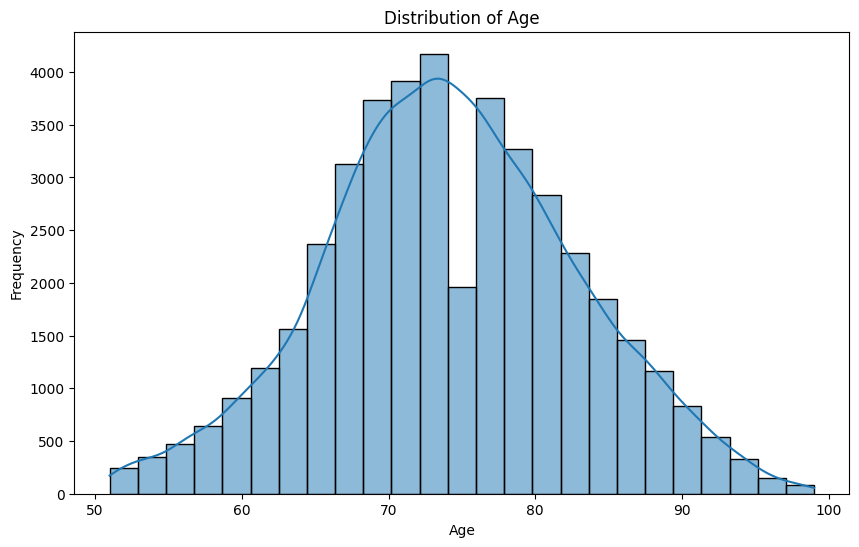

43166


In [ ]:
# Plot of ages of all subjects, including those with missing data
plt.figure(figsize=(10, 6))
sns.histplot(data['NACCAGE'], bins=25, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(len(data))
cleaned_data = data

In [ ]:
# Table of how many cases (individuals can be counted more than once) are in each 10-year bin
# Bins are the same as used later for sampling: <60, 60-70, 70-80, 80-90, >90

age_bins_edges = [50, 60, 70, 80, 90, 100]
age_bins = pd.cut(data['NACCAGE'], bins=age_bins_edges, labels=['<60', '60-70', '70-80', '80-90', '>90'])
age_counts = age_bins.value_counts(sort=False)
print(age_counts)

NACCAGE
<60       2622
60-70    11975
70-80    18567
80-90     8533
>90       1469
Name: count, dtype: int64


Correlation - Pearson
Colors indicate the correlation strength: Blue tones represent positive correlations, and red tones indicate negative correlations.
Annotations on the heatmap: These are the actual correlation coefficients, providing precise values for each pair of variables.

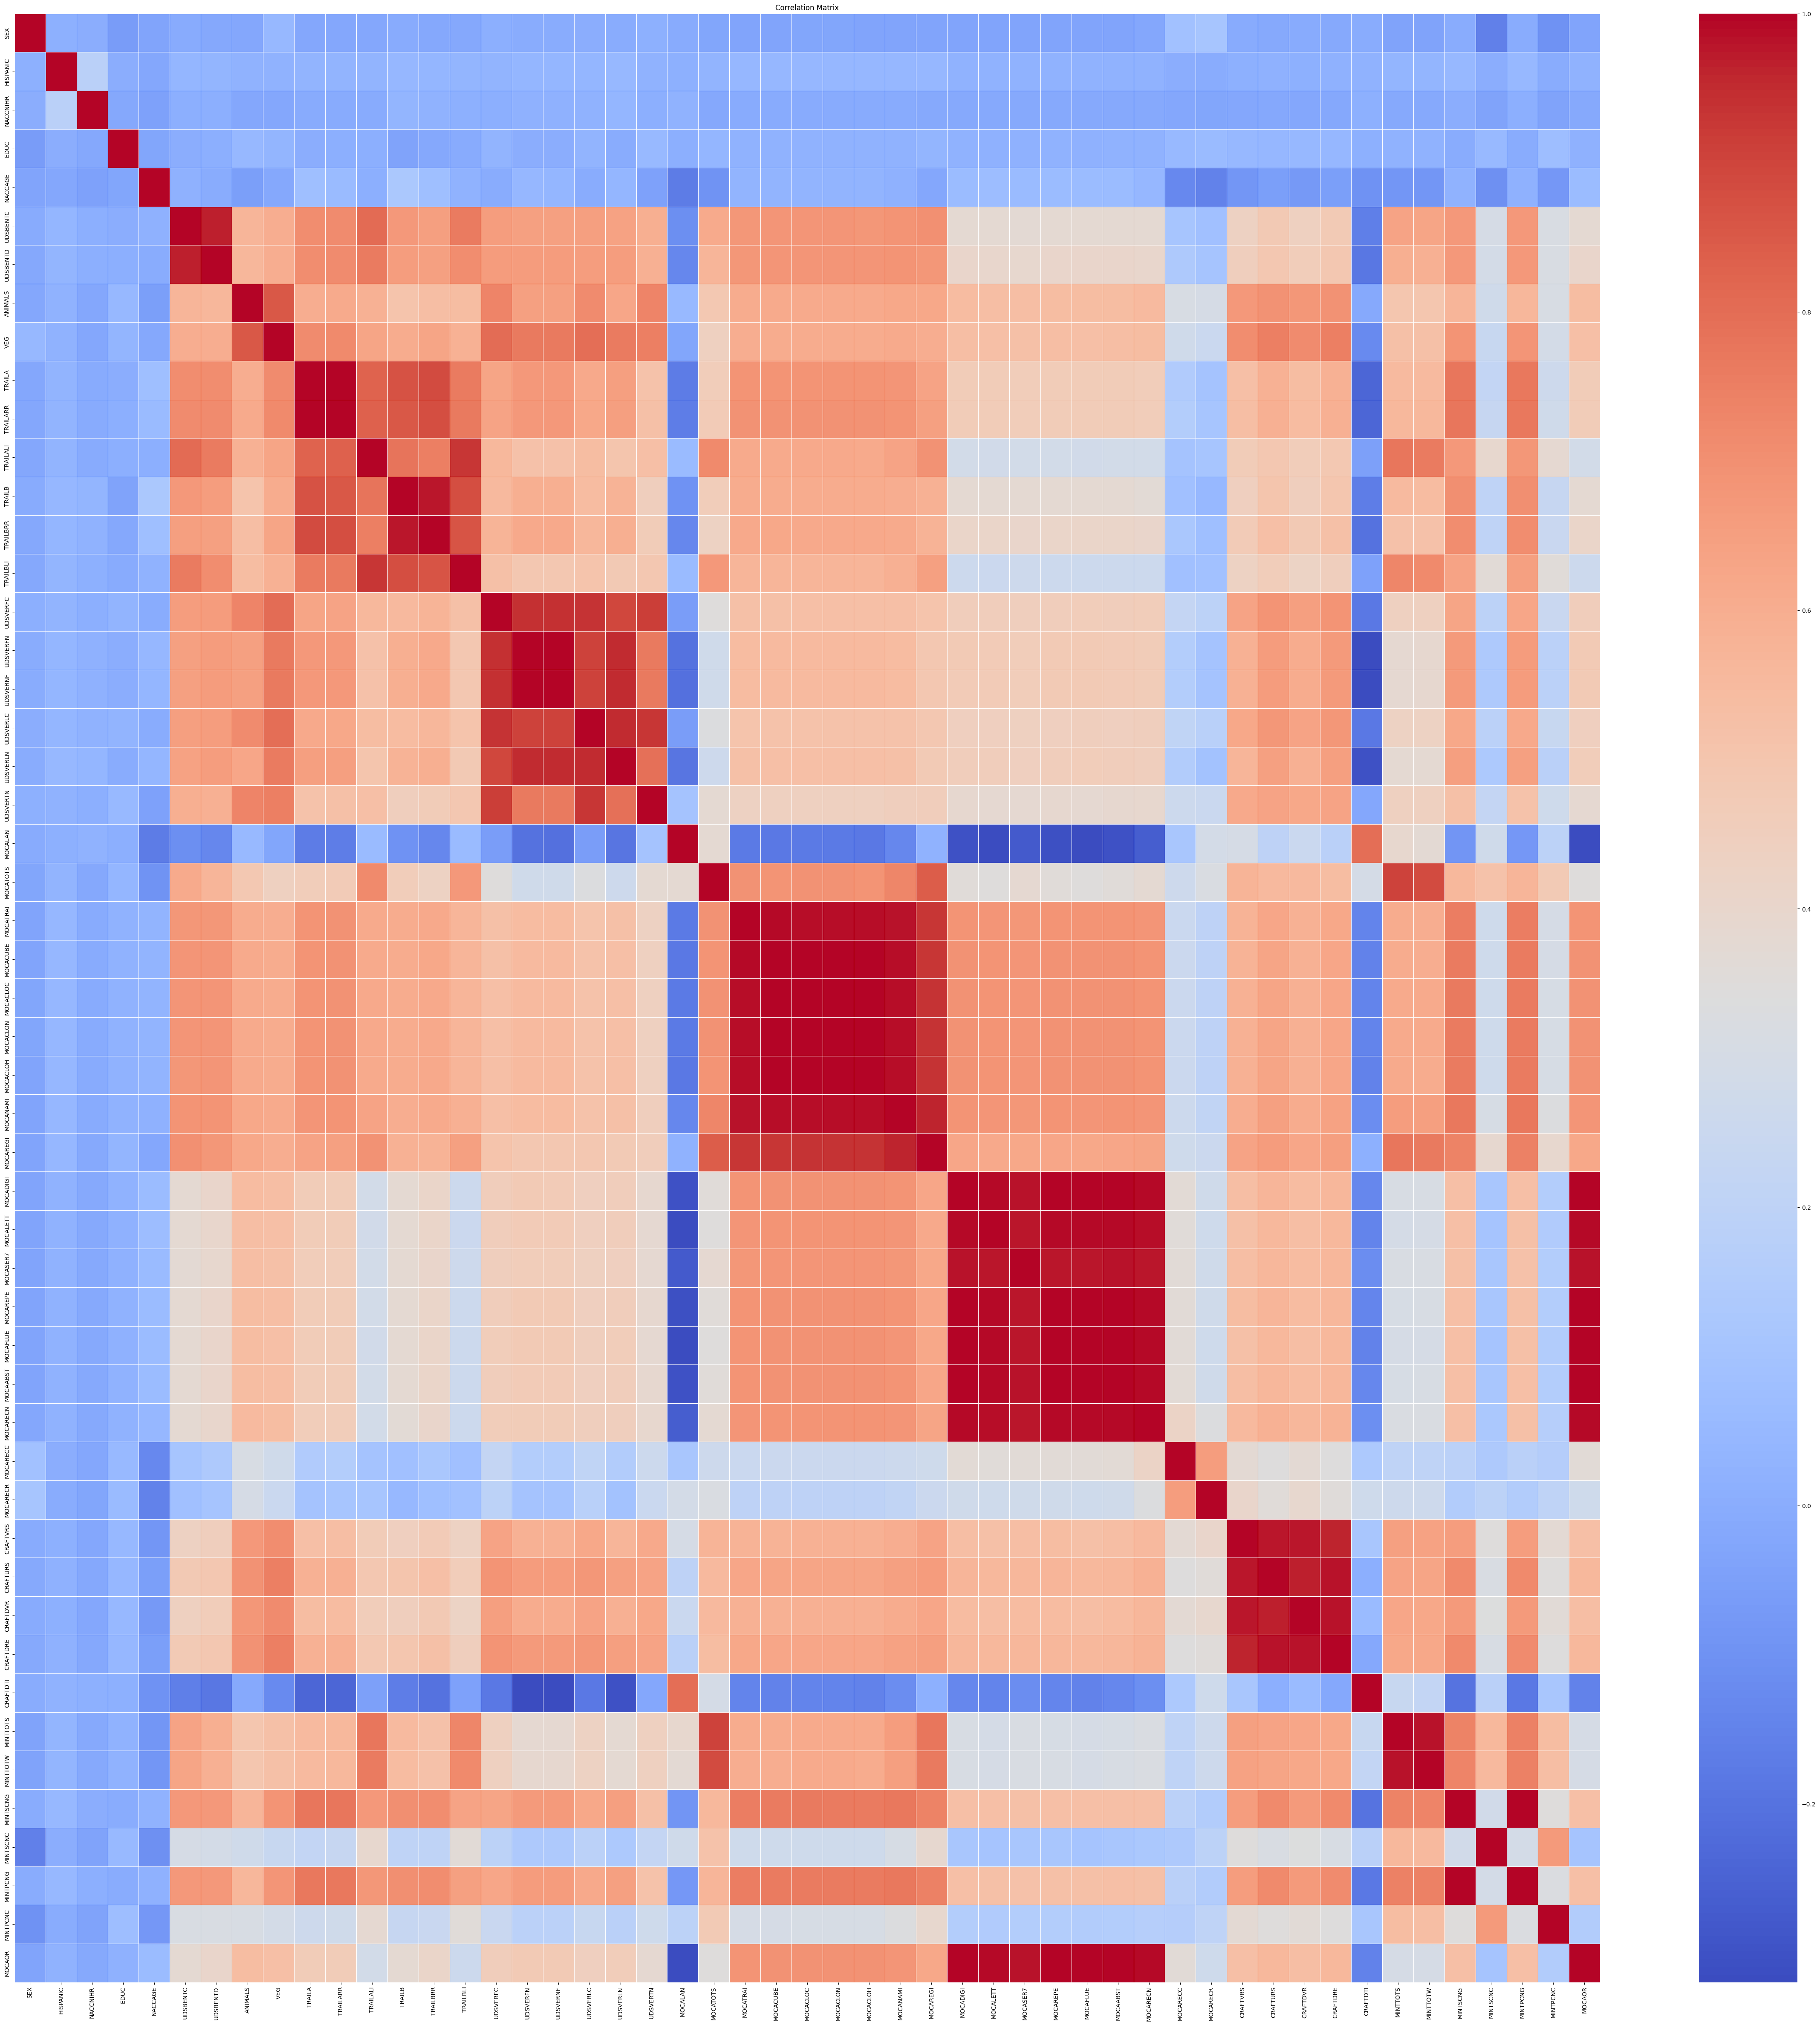

In [ ]:
# Creating correlation matrix for variables in dataframe
correlation_matrix = data.corr()  # Computes the Pearson correlation coefficient by default

# Display the correlation matrix
# print(correlation_matrix)
plt.figure(figsize=(60, 60))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## Data = All of the subjects with missing data
Testing and training first rf model using all 43000 cases in NACC dataset, including all timepoints for each individual and cases with some missing data.

In [ ]:
# Running random forest regression model for all subjects
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

# Assigning variables (fixed is all but age, target is age)
X = data.drop('NACCAGE', axis=1)
y = data['NACCAGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Naming columns for later feature selection
feature_names = X.columns

# Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)


predictions_model = rf.predict(X_test)

mse = mean_squared_error(y_test, predictions_model)

rmse = mean_squared_error(y_test, predictions_model, squared=False)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print("Feature Importances:", rf.feature_importances_)

mae = mean_absolute_error(y_test, predictions_model)

print(f"Mean Absolute error: {mae}")

r_squared = r2_score(y_test, predictions_model)
print("R-squared:", r_squared)
adjusted_r_squared = 1 - (1 - r_squared) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1))
print("Adjusted R-squared:", adjusted_r_squared)


Mean Squared Error: 55.46912437350314
Root Mean Squared Error: 7.447759688221898
Feature Importances: [0.01059618 0.01455512 0.03306835 0.04398885 0.01840813 0.03667777
 0.05832956 0.04523379 0.07527609 0.00518686 0.00074269 0.1113911
 0.00897933 0.00132486 0.03347308 0.02035651 0.01000512 0.03288907
 0.00867593 0.03515156 0.00225744 0.01861801 0.00408954 0.00436002
 0.00086767 0.00215861 0.0037455  0.00850179 0.06133306 0.00435577
 0.0033259  0.00622441 0.00827079 0.00493841 0.00701954 0.01826364
 0.01261289 0.01075715 0.03096956 0.02424468 0.03126934 0.02519795
 0.03525266 0.00925599 0.0118963  0.01261652 0.00798439 0.01061146
 0.01012672 0.00456435]
Mean Absolute error: 5.879901942254188
R-squared: 0.25971954512373674
Adjusted R-squared: 0.25886104987280756


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Slope of the regression line: 0.26812336204676046


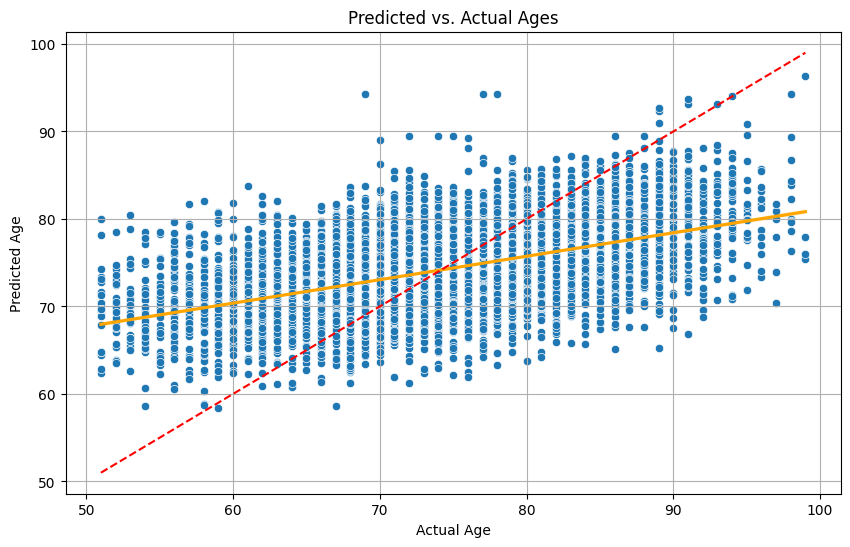

In [ ]:
# Creating scatterplot of predictions from model, as well as calculating and plotting regression line

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

actual_ages = y_test
predicted_ages = predictions_model

# Create a scatter plot and calculate slope
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_ages, y=predicted_ages, marker='o')
sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(actual_ages, predicted_ages)

print("Slope of the regression line:", slope)

# Plot a line of perfect prediction (identity line)
plt.plot([min(actual_ages), max(actual_ages)], [min(actual_ages), max(actual_ages)], color='red', linestyle='--')

plt.title('Predicted vs. Actual Ages')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.grid(True)
plt.show()

In [ ]:
print (len(data))
print(data.head())

43166
   SEX  HISPANIC  NACCNIHR  EDUC  NACCAGE  UDSBENTC  UDSBENTD  ANIMALS  VEG  \
0    1         1         1    12       77        15        17       23   17   
1    1         1         1    18       74        16         9       10   19   
2    2         1         1    14       70        17         8       15   16   
3    1         1         6    13       84        17         9       17   17   
4    2         0         1    16       64        15        15       32   15   

   TRAILA  ...  CRAFTDVR  CRAFTDRE  CRAFTDTI  MINTTOTS  MINTTOTW  MINTSCNG  \
0      63  ...        15        13        22        30        30         2   
1      23  ...        18        13        20        30        30         2   
2      44  ...         6         6        20        29        29         3   
3      25  ...        10         9        20        32         0         0   
4      29  ...        24        15        20        32         0        32   

   MINTSCNC  MINTPCNG  MINTPCNC  MOCAOR  
0       

## Creating test sample with replacement to account for age weighting
In order to address over- and underfitting at extremely young and old points, create a sample set from data with replacement to oversample from extremes and undersample from middle (60-90). Run rf the same way as before using new sampled dataset.

1469
2938
18567
1469
count    11752.000000
mean        75.377893
std         11.426197
min         51.000000
25%         67.000000
50%         75.000000
75%         84.000000
max         99.000000
Name: NACCAGE, dtype: float64


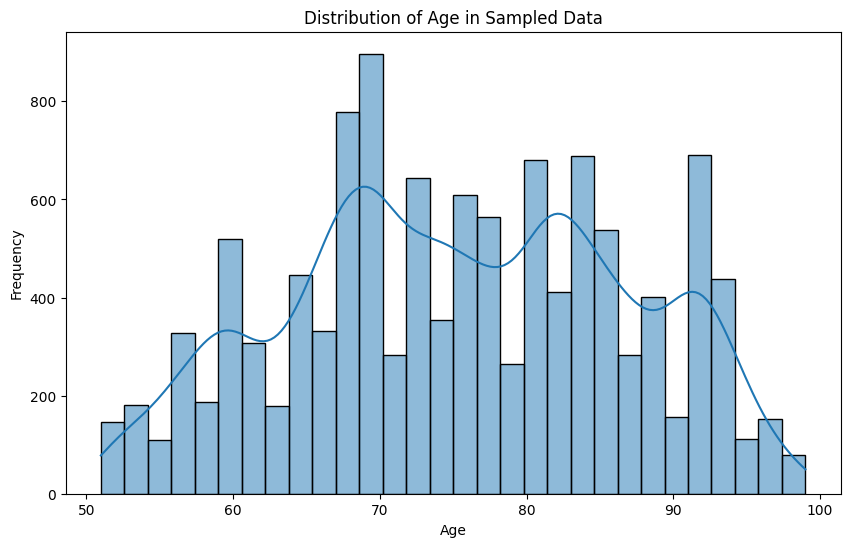

       SEX  HISPANIC  NACCNIHR  EDUC  NACCAGE  UDSBENTC  UDSBENTD  ANIMALS  \
16098    1         0         1    16       78        15        10       23   
26010    2         0         1    12       97        -4        -4       -4   
16943    2         0         1    16       73        -4        -4       -4   
17924    2         0         1    17       98        -4        -4       -4   
14631    1         0         1    12       67        16        14       20   

       VEG  TRAILA  ...  CRAFTDVR  CRAFTDRE  CRAFTDTI  MINTTOTS  MINTTOTW  \
16098    9      31  ...        21        18        21        31        31   
26010   -4      -4  ...        -4        -4        -4        -4        -4   
16943   -4      -4  ...        -4        -4        -4        -4        -4   
17924   -4      -4  ...        -4        -4        -4        -4        -4   
14631   11      17  ...        24        19        22        32        32   

       MINTSCNG  MINTSCNC  MINTPCNG  MINTPCNC  MOCAOR  
16098       

In [ ]:
# Sampling full NACC dataset to adjust for over- and underfitting

# Calculate the number of samples in each age group
age_groups = pd.cut(data['NACCAGE'], bins=[0, 60, 70, 80, 90, 120], labels=['<60', '60-70', '70-80', '80-90', '>90'])
group_counts = age_groups.value_counts()

# Determine the size of the largest and smallest groups to set "weights"
max_group_size = group_counts.max()
min_group_size = group_counts.min()
outer_bin_weight = min_group_size
inner_bin_weight = 2 * min_group_size
print(outer_bin_weight)
print(inner_bin_weight)
print(max_group_size)
print(min_group_size)

# Sample with replacement from each age group
# Per feedback: extreme bins (<60 and >90) sampled at min group size and middle three bins samples 2x min group
sampled_data = pd.concat([
    data[age_groups == '<60'].sample(outer_bin_weight, replace=True),
    data[age_groups == '60-70'].sample(inner_bin_weight, replace=True),
    data[age_groups == '70-80'].sample(inner_bin_weight, replace=True),
    data[age_groups == '80-90'].sample(inner_bin_weight, replace=True),
    data[age_groups == '>90'].sample(outer_bin_weight, replace=True)
])

# Shuffle the sampled data
sampled_data = sampled_data.sample(frac=1, random_state=42)  # Set a random state for reproducibility

# Verify the distribution of ages in the sampled data
print(sampled_data['NACCAGE'].describe())
plt.figure(figsize=(10, 6))
sns.histplot(sampled_data['NACCAGE'], bins=30, kde=True)
plt.title('Distribution of Age in Sampled Data')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(sampled_data.head())


In [ ]:
print(len(sampled_data))

11752


In [ ]:
#RF for sampled dataset (including missing values)

# Assigning variables (fixed is all but age, target is age)
X = sampled_data.drop('NACCAGE', axis=1)
y = sampled_data['NACCAGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Naming columns for later feature selection
feature_names = X.columns

# Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)


predictions_sampled_model = rf.predict(X_test)

mse = mean_squared_error(y_test, predictions_sampled_model)

rmse = mean_squared_error(y_test, predictions_sampled_model, squared=False)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print("Feature Importances:", rf.feature_importances_)

mae = mean_absolute_error(y_test, predictions_sampled_model)

print(f"Mean Absolute error: {mae}")

r_squared = r2_score(y_test, predictions_sampled_model)
print("R-squared:", r_squared)
adjusted_r_squared = 1 - (1 - r_squared) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1))
print("Adjusted R-squared:", adjusted_r_squared)

Mean Squared Error: 62.836794440581244
Root Mean Squared Error: 7.92696628229118
Feature Importances: [0.01156189 0.01855133 0.03727511 0.04412797 0.01518447 0.03553332
 0.06734928 0.04668726 0.0735185  0.00322844 0.00039734 0.14660422
 0.00752863 0.00093128 0.02855571 0.02066095 0.00967605 0.02662522
 0.00648759 0.02718658 0.00297781 0.01696035 0.00696319 0.00399741
 0.00053981 0.00241898 0.00441682 0.01495284 0.07152262 0.00378953
 0.00232376 0.00462561 0.00633376 0.00336144 0.00542974 0.02050457
 0.01250986 0.0092966  0.02448501 0.0186175  0.02430495 0.01964749
 0.03251041 0.009913   0.011425   0.0092253  0.00744526 0.00938742
 0.00816793 0.00427493]
Mean Absolute error: 6.141279271016303
R-squared: 0.5324544932487092
Adjusted R-squared: 0.5304566062871192


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Slope of the regression line: 0.49188450853641474


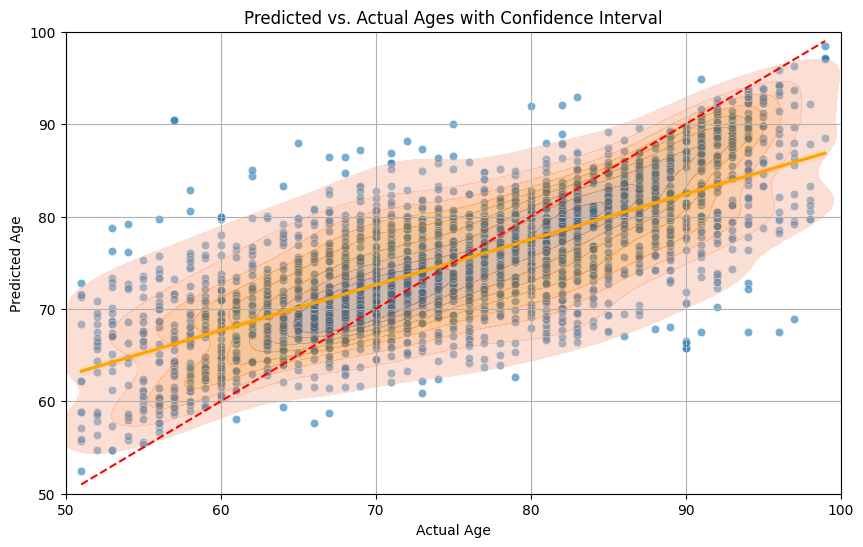

Slope of the regression line: 0.49188450853641474


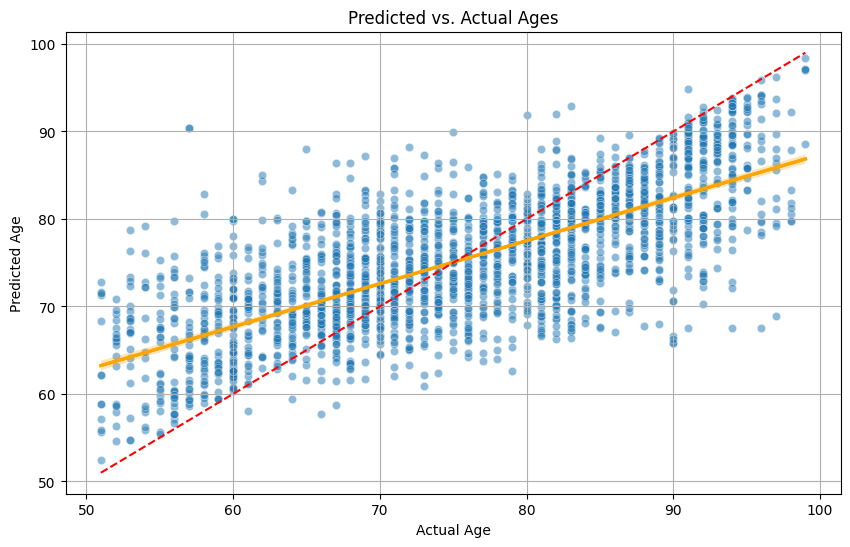

In [ ]:
# Plot for sampled data rf, both scatter of predictions and regression line

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

actual_ages = y_test
predicted_ages = predictions_sampled_model


# Create a scatter plot with density and confidence interval
plt.figure(figsize=(10, 6))
# Scatter plot with adjusted transparency for density view
sns.scatterplot(x=actual_ages, y=predicted_ages, marker='o', alpha=0.6)

# Regression line with confidence interval
sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange', ci=95)

# Regression line details
slope, intercept, r_value, p_value, std_err = stats.linregress(actual_ages, predicted_ages)
print("Slope of the regression line:", slope)
# Add the filled confidence interval
sns.kdeplot(x=actual_ages, y=predicted_ages, fill=True, alpha=0.4)

# Perfect prediction line
plt.plot([min(actual_ages), max(actual_ages)], [min(actual_ages), max(actual_ages)], color='red', linestyle='--')

# Set x and y limits for the plot range
plt.xlim(min(actual_ages) - 1, max(actual_ages) +1)
plt.ylim(min(actual_ages) - 1, max(actual_ages) +1)

# Titles and labels
plt.title('Predicted vs. Actual Ages with Confidence Interval')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.grid(True)

plt.show()




# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_ages, y=predicted_ages, marker='o', alpha = 0.5)
sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(actual_ages, predicted_ages)

print("Slope of the regression line:", slope)


# Adding in confidence interval to show density

# Generate predictions and compute confidence intervals
x_vals = np.linspace(min(actual_ages), max(actual_ages), 100)
y_vals = slope * x_vals + intercept
confidence_interval = 1.96 * std_err  # 95% confidence interval
#sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange', line_kws={"label": "Regression Line"})

# Plot confidence intervals as shaded region
plt.fill_between(x_vals, (y_vals - confidence_interval), (y_vals + confidence_interval), color='blue', alpha=0.3, label='95% CI')

# Regression line with confidence interval
sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange', ci=95)

# Plot a line of perfect prediction
plt.plot([min(actual_ages), max(actual_ages)], [min(actual_ages), max(actual_ages)], color='red', linestyle='--')

plt.title('Predicted vs. Actual Ages')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.grid(True)
plt.show()

## Correcting Penn UDS data to include test date

Single visit data for Penn only, correcting dataframe to include test date, which is needed in regional superager analyses to match closest MRI scan. Need to run to import Penn dataset and adjust format (change column names, calculate earliest visits, etc) so that this dataset will be accepted by random forest model.

In [ ]:
# Adjusting Penn only dataset to fit random forest model format because first attempt did not include test date

# Load Penn-only UDS
file_path = '/content/drive/Shareddrives/Cognitive Age Project/INQuery_Output_FULL(2024.08.02).csv'
penn_only_data = pd.read_csv(file_path)
#print(len(penn_only_data))
penn_only_data['MOCAOR'] = penn_only_data ['MOCAORDT'] + penn_only_data ['MOCAORMO'] + penn_only_data ['MOCAORYR'] + penn_only_data ['MOCAORDY'] + penn_only_data ['MOCAORPL'] + penn_only_data ['MOCAORCT']
listOfVar= ['MOCAORDT' , 'MOCAORMO', 'MOCAORYR' , 'MOCAORDY','MOCAORPL' , 'MOCAORCT', ]
for i in listOfVar:
  penn_only_data  = penn_only_data.drop(i+'', axis=1)
print(len(penn_only_data))

# Remove all rows that have NA in ADI column
penn_only_data = penn_only_data.dropna(subset = 'ADI2020_STATERNK_v4_0_1')
penn_only_data = penn_only_data[~penn_only_data['ADI2020_STATERNK_v4_0_1'].str.contains('PH|GQ')]

# Convert ADI to integer
penn_only_data['ADI2020_STATERNK_v4_0_1'] = penn_only_data['ADI2020_STATERNK_v4_0_1'].astype(int)
print(type(penn_only_data['ADI2020_STATERNK_v4_0_1']))

# Changing column names of demographic columns to match NACC training data
penn_only_data.rename(columns={'Ethnicity': 'HISPANIC', 'Sex': 'SEX', 'Race': 'NACCNIHR', 'Education': 'EDUC', 'AgeatTest': 'NACCAGE'}, inplace=True)

# Excluding rows with age < 50 and > 100
penn_only_data = penn_only_data[~((penn_only_data['NACCAGE'] <= 50))]
penn_only_data = penn_only_data[~((penn_only_data['NACCAGE'] >= 100))]

# Changing code for SEX (1=Male, 2=Female)
penn_only_data['SEX'] = penn_only_data['SEX'].replace({'Male': 1, 'Female': 2})

# Changing code for HISPANIC (0=No, 1=Yes, 9=Unknown)
penn_only_data['HISPANIC'] = penn_only_data['HISPANIC'].apply(
    lambda x: 0 if x == 'Not Hispanic or Latino'
    else 1 if x == 'Hispanic or Latino'
    else 9
)

# Changing code for NACCNIHR (1=White, 2=Black or African American, 3=American Indian or Alaska Native, 4=Native Hawaiian or Pacific Islander, 5=Asian, 6=Multiracial, 99=Unknown or ambiguous)
penn_only_data['NACCNIHR'] = penn_only_data['NACCNIHR'].apply(
    lambda x: 1 if x == 'White'
    else 2 if x == 'Black or African American'
    else 3 if x == 'American Indian or Alaska Native'
    else 4 if x == 'Native Hawaiian or Pacific Islander'
    else 5 if x == 'Asian'
    else 6 if x == 'More than One Race'
    else 99 if x == 'Unknown or Not Reported'
    else 99
)

print(type(penn_only_data))

1779
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


<ipython-input-15-6bbff63f5fdb>:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  penn_only_data['SEX'] = penn_only_data['SEX'].replace({'Male': 1, 'Female': 2})


In [ ]:
# Cut down to single visit: chronologically first visit for each individual

penn_only_data.rename(columns={'TestDate': 'TESTDATE'}, inplace=True)
penn_only_data['TESTDATE'] = pd.to_datetime(penn_only_data['TESTDATE'], format='%m/%d/%Y')
penn_only_data = penn_only_data.sort_values(by=['INDDID', 'TESTDATE'])
print(penn_only_data.head())
penn_only_data = penn_only_data.drop_duplicates(subset='INDDID', keep='first')

# Dropping columns that are not in model (various tests, demographics)
# Still need to keep a few columns like ADI, Test Date, etc
col_to_keep = ['INDDID', 'ADI2020_STATERNK_v4_0_1', 'TESTDATE']
for col in data.columns:
  col_to_keep.append(col)
penn_only_data  = penn_only_data[col_to_keep]
#penn_only_data = penn_only_data.dropna()
print(penn_only_data.head())
print(penn_only_data.columns)
print(len(penn_only_data))

     INDDID DiagnosisDate ADCCDx1   YOB  NACCNIHR  HISPANIC  SEX  EDUC  \
0  100049.0    04/27/2015  Normal  1941         1         0    2  18.0   
1  100049.0    02/14/2017  Normal  1941         1         0    2  18.0   
2  100049.0    05/18/2017  Normal  1941         1         0    2  18.0   
3  100049.0    05/02/2018  Normal  1941         1         0    2  18.0   
4  100085.0    04/27/2015  Normal  1922         1         0    1  11.0   

   ADI2020_STATERNK_v4_0_1   TESTDATE  ...  WordListRecognitionTotal_Z  \
0                        1 2015-04-23  ...                         NaN   
1                        1 2017-05-04  ...                         NaN   
2                        1 2017-05-04  ...                         NaN   
3                        1 2018-05-02  ...                         NaN   
4                        2 2015-04-14  ...                         NaN   

  MINTTOTS_Z ANIMALS_Z  VEG_Z  UDSVERFC_Z  UDSVERLC_Z  UDSVERTN_Z  \
0       -1.7      -0.3   -1.6        -0.4

##Prediction using Penn-only dataset, baseline visit

Generating cognitive age predictions for all individuals in Penn dataset and calculating residuals.


In [ ]:
# Generate predictions on Penn dataset using random forest model

import pandas as pd

#Using fixed penn_only_data that includes test date
penn_only_data = penn_only_data.dropna()

# Select the relevant features from Penn dataset (exclude NACCAGE, ID, ADI, Date)
X_new = penn_only_data.drop(columns=['INDDID', 'NACCAGE', 'ADI2020_STATERNK_v4_0_1', 'TESTDATE'])

# Make predictions for Penn dataset using already-trained rf model
predictions_penn = rf.predict(X_new)

print(predictions_penn)


[73.37       90.07       73.02       67.86       85.89       59.61
 70.23       70.25       60.56       72.76       72.45       72.99
 72.71       71.25       67.27       76.93       72.93       75.87
 67.98       81.35       84.28       80.23       64.86       82.62
 84.85       70.51       67.79       68.64       84.6        76.63
 74.82       65.72       82.55       72.54       85.37       69.67
 71.96       67.46       69.96       70.68       70.49       64.91
 90.39       67.49       67.         64.09       67.51       63.51
 64.         68.41       73.68       74.64       67.73       69.39
 79.51       67.33       65.76       68.76       85.86       76.92
 69.03       76.7        71.44       80.3        63.83       75.95
 78.21       74.09       82.55       71.74       62.85       79.71
 75.31       65.4        74.49       70.65       78.08       66.23
 71.29       75.81       77.34       69.26       66.49       65.96
 70.01       66.85       82.61       88.36       70.57       8

Slope of the regression line: 0.49188450853641474


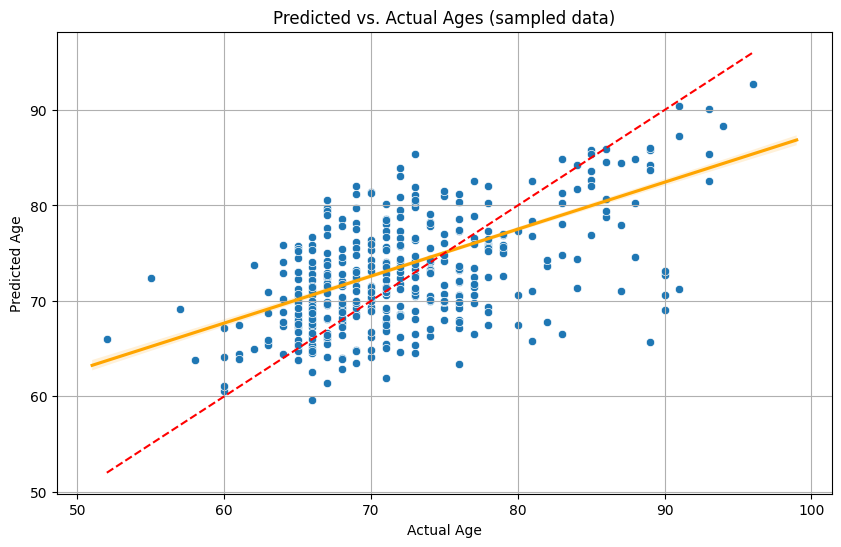

In [ ]:
# Using scatterplot to visualize actual age from Penn dataset vs predictions from rf
# Needs to be done in a way that compares points from Penn dataset to regression line from whole dataset rf
# Don't generate new regression line based on Penn data

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

actual_ages_penn = penn_only_data['NACCAGE']
predicted_ages_penn = predictions_penn

# Create scatter plot and calculate/visualize regression line

plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_ages_penn, y=predicted_ages_penn, marker='o')
sns.regplot(x=actual_ages, y=predicted_ages, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(actual_ages, predicted_ages)

print("Slope of the regression line:", slope)

plt.plot([min(actual_ages_penn), max(actual_ages_penn)], [min(actual_ages_penn), max(actual_ages_penn)], color='red', linestyle='--')

plt.title('Predicted vs. Actual Ages (sampled data)')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.grid(True)
plt.show()


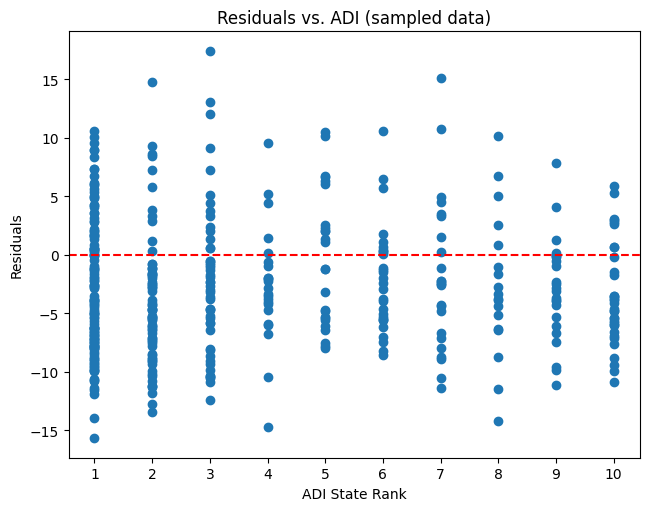

In [ ]:
# Plotting relationship between predictions and ADI using residuals
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Calculate residuals
residuals = predictions_penn - np.mean(predictions_sampled_model)
penn_only_data['residuals'] = residuals


# Plot residuals vs ADI
plt.scatter(penn_only_data.loc[actual_ages_penn.index, 'ADI2020_STATERNK_v4_0_1'], residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(ticks=penn_only_data['ADI2020_STATERNK_v4_0_1'].unique(),
           labels=penn_only_data['ADI2020_STATERNK_v4_0_1'].unique())
plt.tight_layout()
plt.xlabel('ADI State Rank')
plt.ylabel('Residuals')
plt.title('Residuals vs. ADI (sampled data)')
plt.show()


In [ ]:
# Assessing relationship between residuals and ADI
from scipy.stats import pearsonr, spearmanr

# Calculate Pearson correlation
pearson_corr, pearson_p_value = pearsonr(residuals, penn_only_data['ADI2020_STATERNK_v4_0_1'])
print(f'Pearson correlation: {pearson_corr}, p-value: {pearson_p_value}')

# Calculate Spearman correlation
spearman_corr, spearman_p_value = spearmanr(residuals, penn_only_data['ADI2020_STATERNK_v4_0_1'])
print(f'Spearman correlation: {spearman_corr}, p-value: {spearman_p_value}')


Pearson correlation: 0.026415008279188662, p-value: 0.5875379844791034
Spearman correlation: 0.05262005266925245, p-value: 0.2796688134687924


count    424.000000
mean      -2.750127
std        5.638685
min      -15.677510
25%       -6.690010
50%       -3.587510
75%        0.469990
max       17.422490
Name: residuals, dtype: float64


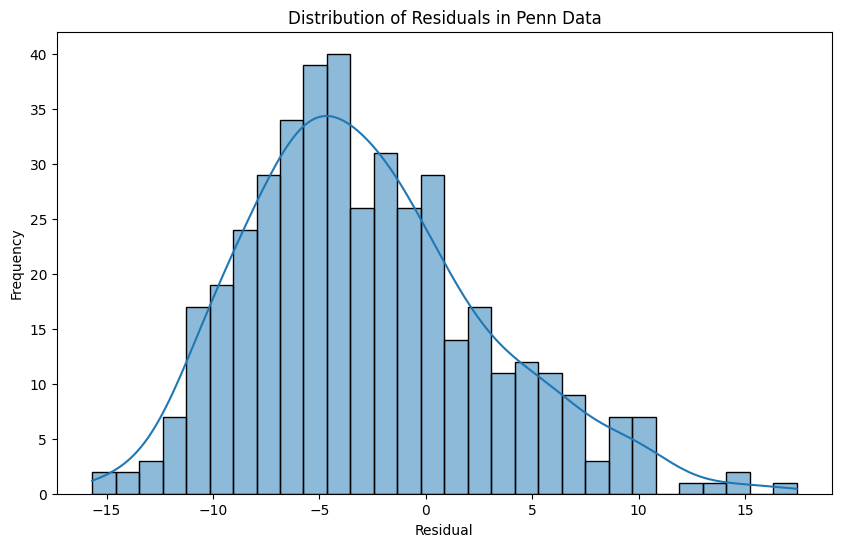

In [ ]:
# Creating plot to show frequency of residuals
# Bin residuals into bins with width of like 2 to do bar plot of frequency

# Bar plot showing frequency of residual bins in Penn dataset
print(penn_only_data['residuals'].describe())
plt.figure(figsize=(10, 6))
sns.histplot(penn_only_data['residuals'], bins=30, kde=True) # ADJUST bin size if needed (switch from count to size)
plt.title('Distribution of Residuals in Penn Data')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Saving penn_only_data to look at residual values for indiv older than 80
penn_data_save_path = '/content/drive/Shareddrives/Cognitive Age Project/penn_only_data_301024.csv'
penn_only_data.to_csv(penn_data_save_path, index=False)

In [ ]:
# Assigning decade bins in df_combined
df_combined['Decade'] = (df_combined['NACCAGE'] // 10) * 10

# Print counts of people in each decade by Group assignment
print(df_combined.groupby(['Decade', 'Group']).size())

## Percentile scoring, Penn baseline visit
Generating percentile rank for each individual in Penn dataset based on where they fall in distribution of predictions for those of the same age in model test set.

In [ ]:
# Generating percentile rank based on Penn individuals' baseline visit prediction

import pandas as pd
import numpy as np


# Define a function to calculate percentile rank
def calculate_percentile_rank(value, distribution):
    return (np.sum(distribution <= value) / len(distribution)) * 100

# Create a dictionary of predicted age distributions by age group in the test set
age_distributions = testdf_percentiles.groupby('actual_age')['predicted_age'].apply(list).to_dict()

# Calculate percentile ranks for individuals in the independent dataset
percentile_ranks = []
for _, row in penn_only_data.iterrows():
    actual_age = row['NACCAGE']
    predicted_age = row['predicted_age']

    # Get the distribution for the corresponding age group
    if actual_age in age_distributions:
        distribution = np.array(age_distributions[actual_age])
        percentile_rank = calculate_percentile_rank(predicted_age, distribution)
    else:
        # Handle cases where the age group is not in the test set
        percentile_rank = np.nan  # Or handle appropriately

    percentile_ranks.append(percentile_rank)

# Add percentile ranks to the independent dataset
penn_only_data['percentile_rank'] = percentile_ranks

print(penn_only_data)


        INDDID  ADI2020_STATERNK_v4_0_1   TESTDATE  SEX  HISPANIC  NACCNIHR  \
0     100049.0                        1 2015-04-23    2         0         1   
4     100085.0                        2 2015-04-14    1         0         1   
7     100113.0                        4 2015-04-21    2         0         2   
9     100165.0                        1 2015-08-19    2         0         1   
17    100661.0                        6 2015-12-22    1         0         1   
...        ...                      ...        ...  ...       ...       ...   
1770  131211.0                        1 2024-01-24    2         0         2   
1771  131219.0                        8 2024-02-29    2         0         2   
1772  131241.0                        5 2024-02-08    2         0         2   
1774  131330.0                        5 2024-02-19    1         0         2   
1775  131389.0                        1 2024-03-28    2         0         2   

      EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  MINTT

##Violin plots for ADI vs residuals
Generating violin plots to show relationship between ADI and residuals. Because positive residual is an individual who is cognitively older than their biological age, and because we expect those with more disadvantage (higher ADI) to have more stress, higher ADI should have more positive residuals.

<ipython-input-23-0448eb08dc5c>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  penn_violin_plot = sns.violinplot(x='ADI State Rank', y='Residuals', data=data_for_plot, palette ="coolwarm")


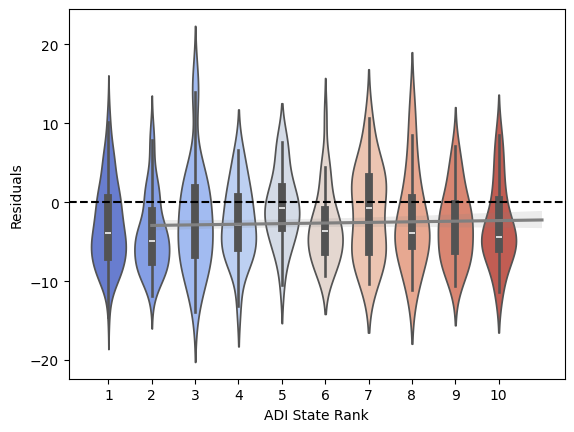

In [ ]:
# Creating violin plot for Penn data (race included) ADI vs residuals
import seaborn as sns
import matplotlib.pyplot as plt

# Pull 'ADI2020_STATERNK_v4_0_1' from penn_only_data and residuals from NumPy array
data_for_plot = {'ADI State Rank': penn_only_data['ADI2020_STATERNK_v4_0_1'],
                 'Residuals': residuals}

# Visualize plot
penn_violin_plot = sns.violinplot(x='ADI State Rank', y='Residuals', data=data_for_plot, palette ="coolwarm")
sns.regplot(x='ADI State Rank', y='Residuals', data=data_for_plot, scatter=False, ax=penn_violin_plot, color='gray')
plt.xlabel("ADI State Rank")

# Add x-axis at y=0
penn_violin_plot.axhline(y=0, color='black', linestyle='--')
plt.show()

# Superager analyses using rf model

Using model to analyze relationship between predicted cognitive age and measures of interest, like cortical thickness/MTL volume metrics. Anticipate that individuals who fall more towards resilient end of the spectrum (percentile rank closer to 0) will have higher thicknesses and volumes in ROIs: MTL, ACC, MFC. Conducting this analysis both categorically (resilient vs vulnerable quartiles) and continuously (across entire spectum of percentile ranks).

##Stratifying model output to identify superager group using residuals
This group contains individuals from the Penn dataset identified as cognitively resilient using residuals, falling 1 standard deviation or more below the regression line.

In [ ]:
# Isolate vulnerable group (1 or more st dev above regression line) and resilient group (1 or more st dev below regression line)
# Use residuals to ID those above or below threshold

# Use residuals for Penn-only dataset predictions (residuals = predicted_age_penn - regression)
# Positive residual is vulnerable, negative residual is resilient

# Assign residuals as penn_only_data residuals in case of name reassignment somewhere in code
residuals = penn_only_data['residuals']

# Calculate standard deviation of residuals
residuals_stdev = np.std(residuals)
vulner_thresh = residuals_stdev
resil_thresh = -residuals_stdev

# Create two dataframes
vulnerable = penn_only_data[penn_only_data['residuals'] > vulner_thresh]
resilient = penn_only_data[penn_only_data['residuals'] < resil_thresh]

# Check length of dataframes
print(len(vulnerable))
print(len(resilient))

33
152


In [ ]:
# Save initial list of vulnerable and resilient individuals to csv file
vul_save_path = '/content/drive/Shareddrives/Cognitive Age Project/vulnerable_indiv_102124.csv'
vulnerable.to_csv(vul_save_path, index=False)
resil_save_path = '/content/drive/Shareddrives/Cognitive Age Project/resilient_indiv_102124.csv'
resilient.to_csv(resil_save_path, index=False)


In [ ]:
# TEMPORARY: import vulnerable and resil tables from first run
vulnerable = pd.read_csv('/content/drive/Shareddrives/Cognitive Age Project/vulnerable_indiv.csv')
resilient = pd.read_csv('/content/drive/Shareddrives/Cognitive Age Project/resilient_indiv.csv')

In [ ]:
print("Duplicate IDs in cog_data:", penn_only_data['INDDID'][penn_only_data['INDDID'].duplicated()])
print(penn_only_data.head())

Duplicate IDs in cog_data: Series([], Name: INDDID, dtype: float64)
     INDDID  ADI2020_STATERNK_v4_0_1    TESTDATE  SEX  HISPANIC  NACCNIHR  \
0  100049.0                        1  2015-04-23    2         0         1   
1  100085.0                        2  2015-04-14    1         0         1   
2  100113.0                        4  2015-04-21    2         0         2   
3  100165.0                        1  2015-08-19    2         0         1   
4  100661.0                        6  2015-12-22    1         0         1   

   EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  CRAFTDRE  CRAFTDTI  MINTTOTS  \
0  18.0     73.0      16.0       5.0  ...      12.0      19.0      28.0   
1  11.0     93.0      16.0       9.0  ...      12.0      15.0      31.0   
2  12.0     65.0      13.0       9.0  ...      12.0      20.0      24.0   
3  18.0     68.0      16.0      12.0  ...      21.0      16.0      32.0   
4  18.0     86.0      14.0       8.0  ...      15.0      21.0      32.0   

   MINTTOTW  MINTS

In [ ]:
# Import and merge in thickness and volume measures
thickness_path = '/content/drive/Shareddrives/Cognitive Age Project/ABC_3T_thickness_20240715.csv'
thickness_data = pd.read_csv(thickness_path)
thickness_data = thickness_data.rename(columns = {'INDD' : 'INDDID'})
thickness_data['INDDID'] = thickness_data['INDDID'].astype(float)
#penn_only_data['INDDID'] = penn_only_data['INDDID'].astype(float)

# Include only one scan for each individual
# Ensure this scan is closest in date to the cognitive test date (TESTDATE)
thickness_data['MRIDATE'] = pd.to_datetime(thickness_data['MRIDATE'], format='%Y%m%d', errors='coerce')
# Start by adding in 'TESTDATE' for each indiv into all thickness_data rows for that indiv
penn_only_data['TESTDATE'] = pd.to_datetime(penn_only_data['TESTDATE'], format='%Y-%m-%d', errors='coerce')
thickness_data = pd.merge(thickness_data, penn_only_data[['INDDID', 'TESTDATE']], on='INDDID', how='left')
thickness_data = thickness_data.dropna(subset=['MRIDATE', 'TESTDATE'])

# Calculate the absolute difference between MRIDATE and TESTDATE for every scan row
thickness_data['MRI_Cog_test_distance'] = abs(thickness_data['MRIDATE'] - thickness_data['TESTDATE'])

# Sort by INDDID and MRI_Cog_test_distance, then keep the row with the smallest difference
thickness_data = thickness_data.sort_values(by=['INDDID', 'MRI_Cog_test_distance']).drop_duplicates(subset='INDDID', keep='first')

# Display the first few rows to verify it's loaded correctly
print(thickness_data.head())
print(len(thickness_data))



# Import volume
volume_path = '/content/drive/Shareddrives/Cognitive Age Project/ABC_MRI3T_ASHST1T2_measurements_20240712.csv'
volume_data = pd.read_csv(volume_path)
volume_data = volume_data.rename(columns = {'ID' : 'INDDID'})
volume_data['INDDID'] = volume_data['INDDID'].astype(float)
print(type(volume_data['INDDID'][0]))

# Include only the closest scan to cognitive testing for each individual
volume_data['SCANDATE'] = pd.to_datetime(volume_data['SCANDATE'], format='%Y%m%d', errors='coerce')
volume_data = pd.merge(volume_data, penn_only_data[['INDDID', 'TESTDATE']], on='INDDID', how='left')
volume_data = volume_data.dropna(subset=['SCANDATE', 'TESTDATE'])

# Calculate the absolute difference between MRIDATE and TESTDATE for every scan row
volume_data['Scan_Cog_test_distance'] = abs(volume_data['SCANDATE'] - volume_data['TESTDATE'])

# Sort by INDDID and Scan_Cog_test_distance, then keep the row with the smallest difference
volume_data = volume_data.sort_values(by=['INDDID', 'Scan_Cog_test_distance']).drop_duplicates(subset='INDDID', keep='first')

# Display the first few rows to verify it's loaded correctly
print(volume_data.head())
print(len(volume_data))

# Merge in thickness and volume data into vulner and resil dataframes
full_vulner_data = pd.merge(vulnerable, thickness_data, on='INDDID')
full_vulner_data = pd.merge(full_vulner_data, volume_data, on='INDDID')
print(full_vulner_data.head())

full_resil_data = pd.merge(resilient, thickness_data, on='INDDID')
full_resil_data = pd.merge(full_resil_data, volume_data, on='INDDID')
print(full_resil_data.head())

print(len(full_vulner_data))
print(len(full_resil_data))

      INDDID    MRIDATE  Right_Amygdala_thickness  Left_Amygdala_thickness  \
0   100049.0 2016-06-21                   4.97381                  4.68216   
2   100113.0 2016-06-20                   6.43980                  6.15145   
13  100836.0 2017-02-16                   5.87462                  6.36675   
21  101066.0 2017-06-01                   6.20340                  6.46224   
23  101162.0 2016-05-23                   6.40868                  6.64816   

    Right_Hippocampus_thickness  Left_Hippocampus_thickness  \
0                       3.71692                     3.42221   
2                       3.09184                     2.75015   
13                      3.35842                     3.13814   
21                      3.41054                     3.24426   
23                      3.57493                     3.81179   

    Right_Thalamus_Proper_thickness  Left_Thalamus_Proper_thickness  \
0                           0.32349                         0.20523   
2         

In [ ]:
# Adding AgeAtScan column to use as covariate in linear regression: NACCAGE + MRI_Cog_test_distance (in years)
# First, calculate the days difference between the dates
full_vulner_data['difference_days'] = (full_vulner_data['MRIDATE'] - full_vulner_data['TESTDATE']).dt.days

# Convert positive differences into years and add to 'Age', leaving negatives unchanged
full_vulner_data['AgeAtScan'] = full_vulner_data['NACCAGE'] + full_vulner_data['difference_days'].apply(lambda x: x // 365 if x > 0 else 0)
print(full_vulner_data.head())


# Doing same conversion for resilient dataset
full_resil_data['difference_days'] = (full_resil_data['MRIDATE'] - full_resil_data['TESTDATE']).dt.days

# Convert positive differences into years and add to 'Age', leaving negatives unchanged
full_resil_data['AgeAtScan'] = full_resil_data['NACCAGE'] + full_resil_data['difference_days'].apply(lambda x: x // 365 if x > 0 else 0)
print(full_resil_data.head())


     INDDID  ADI2020_STATERNK_v4_0_1  TESTDATE_x  SEX  HISPANIC  NACCNIHR  \
0  112761.0                        3  2015-06-11    1         0         1   
1  113870.0                        3  2015-04-24    2         0         1   
2  116707.0                        1  2016-05-26    2         0         1   
3  119109.0                        9  2016-02-11    2         0         1   
4  119298.0                        2  2017-03-13    1         0         1   

   EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  M_SUB_VOL_ASHST2_3T  \
0  16.0     94.0      12.0      11.0  ...             977.6940   
1  18.0     91.0      16.0       3.0  ...             684.9860   
2  18.0     84.0      16.0      14.0  ...             937.1130   
3  18.0     72.0      16.0      12.0  ...             990.5775   
4  16.0     89.0      15.0      12.0  ...            1070.5855   

   M_ERC_VOL_ASHST2_3T  M_BA35_VOL_ASHST2_3T  M_BA36_VOL_ASHST2_3T  \
0             842.3820              766.3480             1846.5190   


In [ ]:
# Save full df of vulnerable and resilient individuals with vol/thickness measures to csv file
vul_save_path = '/content/drive/Shareddrives/Cognitive Age Project/vulnerable_thickness_volume_102124.csv'
full_vulner_data.to_csv(vul_save_path, index=False)
resil_save_path = '/content/drive/Shareddrives/Cognitive Age Project/resilient_thickness_volume_102124.csv'
full_resil_data.to_csv(resil_save_path, index=False)

In [ ]:
# TEMPORARY: import vulnerable and resil tables from first run
full_vulner_data = pd.read_csv('/content/drive/Shareddrives/Cognitive Age Project/vulnerable_thickness_volume.csv')
full_resil_data = pd.read_csv('/content/drive/Shareddrives/Cognitive Age Project/resilient_thickness_volume.csv')

In [ ]:
# Run t-test to look for differences btwn ACC and HC measures of vul and resil group
# How to structure: depends on assuming data is normally distributed or not
  # Going to assume yes right now to do t-test, may try w Mann-Whitney later for non-Gaussian
  # Need to do correction?

  # Do this by calculating group mean for each region and running t-test

superager_regions = ['Right_ACgG_anterior_cingulate_gyrus_thickness', 'Left_ACgG_anterior_cingulate_gyrus_thickness',
                    'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                     'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T'
                     ]

# Temporarily fixing missing data:
full_vulner_data = full_vulner_data.dropna(subset=['Right_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'Left_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                                                   'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T'])
full_resil_data = full_resil_data.dropna(subset=['Right_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'Left_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                                                   'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T'])
print(len(full_vulner_data))
print(len(full_resil_data))



# Create dictionary to store t-test statistics and p-values for each region
t_test_results = {'Region': [], 't_stat': [], 'p_value': []}

# Loop through each region and perform an independent t-test
for region in superager_regions:
    vul_values = full_vulner_data[region]
    resil_values = full_resil_data[region]

    # Perform the independent t-test for this region
    t_stat, p_val = stats.ttest_ind(vul_values, resil_values, equal_var=False)  # Assuming unequal variances (Welch's t-test)

    # Store results
    t_test_results['Region'].append(region)
    t_test_results['t_stat'].append(t_stat)
    t_test_results['p_value'].append(p_val)

# Convert the results to a DataFrame
t_test_df = pd.DataFrame(t_test_results)

print(t_test_df)

12
103
                                          Region    t_stat   p_value
0  Right_ACgG_anterior_cingulate_gyrus_thickness -0.957573  0.356205
1   Left_ACgG_anterior_cingulate_gyrus_thickness -0.133819  0.895297
2                         L_AHippo_VOL_ASHST1_3T -2.133312  0.051697
3                         L_PHippo_VOL_ASHST1_3T -4.061898  0.000954
4                         R_AHippo_VOL_ASHST1_3T -0.926595  0.371389
5                         R_PHippo_VOL_ASHST1_3T -3.048962  0.009284


In [ ]:
# Linear regressions to control for intracranial volume (ICV)
import statsmodels.api as sm


# Add a column to each df (vulnerable and resilient) indicating the group
full_vulner_data['Group'] = 0
full_resil_data['Group'] = 1

# Combine the two DataFrames
df_combined = pd.concat([full_vulner_data, full_resil_data])

# Initialize a list to store results for each ROI
results_list = []

# Loop through regions in superager_regions (just doing primary regions first) and conduct linear regression on each
for region in superager_regions:
    print(f"Linear regression results for {region}:")

    # Define the dependent variable (ROI volume) and independent variables (group, ICV, AgeAtScan, and MRI_Cog_test_distance)
    X = df_combined[['Group', 'ICV_ASHST1_3T', 'AgeAtScan', 'MRI_Cog_test_distance']]
    y = df_combined[region]


    # Convert 'MRI_Cog_test_distance' to total days and then to numeric, handling potential errors
    X['MRI_Cog_test_distance'] = pd.to_numeric(X['MRI_Cog_test_distance'].dt.days, errors='coerce')

    # Ensure all columns in X and y are numeric
    X = X.astype(float) # Convert all columns in X to float
    y = y.astype(float) # Convert y to float

    # Add a constant (intercept) to the model
    X = sm.add_constant(X)

    # Fit the linear regression model
    model = sm.OLS(y, X).fit()

    # Extract relevant information
    group_coef = model.params['Group']
    group_pval = model.pvalues['Group']

    # Append results to the list
    results_list.append({'ROI': region, 'Group_Coefficient': group_coef, 'Group_p_value': group_pval})

# Convert results to a DataFrame
results_df = pd.DataFrame(results_list)

# Display the results DataFrame
print(results_df)


Linear regression results for Right_ACgG_anterior_cingulate_gyrus_thickness:
Linear regression results for Left_ACgG_anterior_cingulate_gyrus_thickness:
Linear regression results for L_AHippo_VOL_ASHST1_3T:
Linear regression results for L_PHippo_VOL_ASHST1_3T:
Linear regression results for R_AHippo_VOL_ASHST1_3T:
Linear regression results for R_PHippo_VOL_ASHST1_3T:
                                             ROI  Group_Coefficient  \
0  Right_ACgG_anterior_cingulate_gyrus_thickness           0.324554   
1   Left_ACgG_anterior_cingulate_gyrus_thickness           0.074083   
2                         L_AHippo_VOL_ASHST1_3T         168.956219   
3                         L_PHippo_VOL_ASHST1_3T         165.934736   
4                         R_AHippo_VOL_ASHST1_3T         126.208160   
5                         R_PHippo_VOL_ASHST1_3T         194.390616   

   Group_p_value  
0       0.053419  
1       0.657797  
2       0.068625  
3       0.013814  
4       0.202441  
5       0.003976  


<ipython-input-34-7c5cdbe5c4ac>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['MRI_Cog_test_distance'] = pd.to_numeric(X['MRI_Cog_test_distance'].dt.days, errors='coerce')
<ipython-input-34-7c5cdbe5c4ac>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['MRI_Cog_test_distance'] = pd.to_numeric(X['MRI_Cog_test_distance'].dt.days, errors='coerce')
<ipython-input-34-7c5cdbe5c4ac>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [ ]:
# T-test for secondary regions of interest
superager_secondary_regions = ['L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'
                               ]

# Temporarily fixing missing data:
full_vulner_data = full_vulner_data.dropna(subset=['L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'])
full_resil_data = full_resil_data.dropna(subset=['L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'])
print(len(full_vulner_data))
print(len(full_resil_data))



# Create dictionary to store t-test statistics and p-values for each region
t_test_results_secondary = {'Region': [], 't_stat': [], 'p_value': []}

# Loop through each region and perform an independent t-test
for region in superager_secondary_regions:
    vul_values = full_vulner_data[region]
    resil_values = full_resil_data[region]

    # Perform the independent t-test for this region
    t_stat, p_val = stats.ttest_ind(vul_values, resil_values, equal_var=False)  # Assuming unequal variances (Welch's t-test)

    # Store results
    t_test_results_secondary['Region'].append(region)
    t_test_results_secondary['t_stat'].append(t_stat)
    t_test_results_secondary['p_value'].append(p_val)

# Convert the results to a DataFrame
t_test_secondary_df = pd.DataFrame(t_test_results_secondary)

print(t_test_secondary_df)

12
103
                                      Region    t_stat   p_value
0           L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T -1.130253  0.279656
1           R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T -1.542730  0.149403
2  Right_MFC_medial_frontal_cortex_thickness -1.667306  0.119520
3   Left_MFC_medial_frontal_cortex_thickness -1.070174  0.303688


In [ ]:
# Linear regression for secondary regions of interest

# Initialize a list to store results for each ROI
results_list = []

# Loop through regions in superager_secondary_regions and conduct linear regression on each
for region in superager_secondary_regions:
    print(f"Linear regression results for {region}:")

    # Define the dependent variable (ROI volume) and independent variables (group and ICV, AgeAtScan, MRI_Cog_test_distance)
    X = df_combined[['Group', 'ICV_ASHST1_3T', 'AgeAtScan', 'MRI_Cog_test_distance']]
    y = df_combined[region]

    # Add a constant (intercept) to the model
    X = sm.add_constant(X)

    # Fit the linear regression model
    model = sm.OLS(y, X).fit()

    # Extract relevant information
    group_coef = model.params['Group']
    group_pval = model.pvalues['Group']

    # Append results to the list
    results_list.append({'ROI': region, 'Group_Coefficient': group_coef, 'Group_p_value': group_pval})

# Convert results to a DataFrame
results_df = pd.DataFrame(results_list)

# Display the results DataFrame
print(results_df)

Linear regression results for L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T:
Linear regression results for R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T:
Linear regression results for Right_MFC_medial_frontal_cortex_thickness:
Linear regression results for Left_MFC_medial_frontal_cortex_thickness:
                                         ROI  Group_Coefficient  Group_p_value
0           L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T           0.121077       0.015236
1           R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T           0.104270       0.034554
2  Right_MFC_medial_frontal_cortex_thickness           0.260448       0.054550
3   Left_MFC_medial_frontal_cortex_thickness           0.100093       0.446055


Slope of the regression line: 0.062147896436727


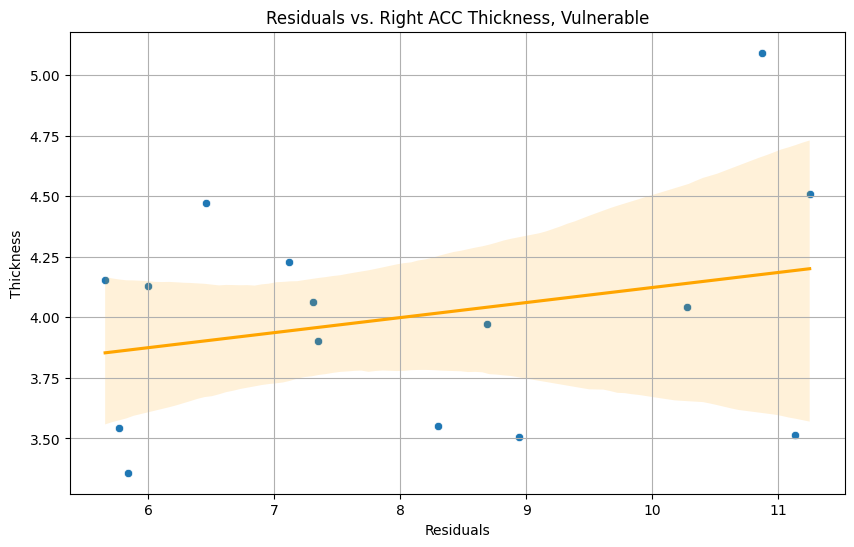

Slope of the regression line: -0.021864263695718634


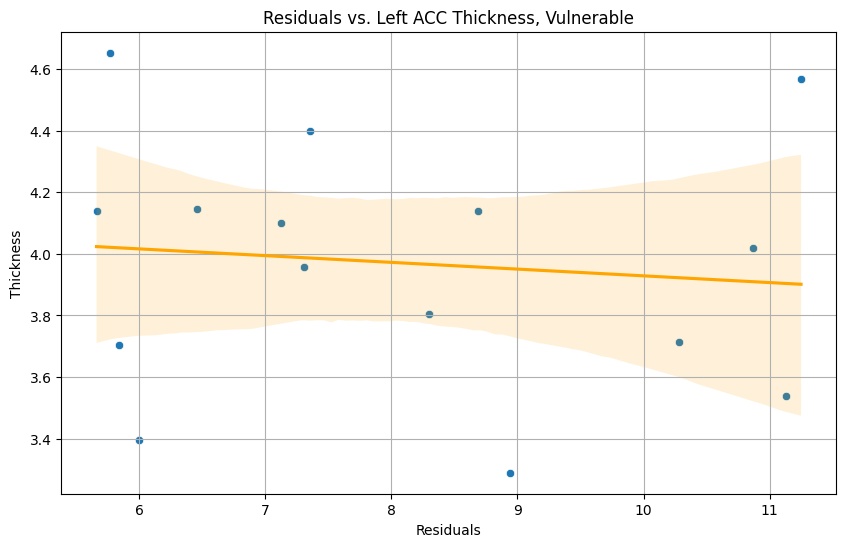

Slope of the regression line: -0.4326843526084495


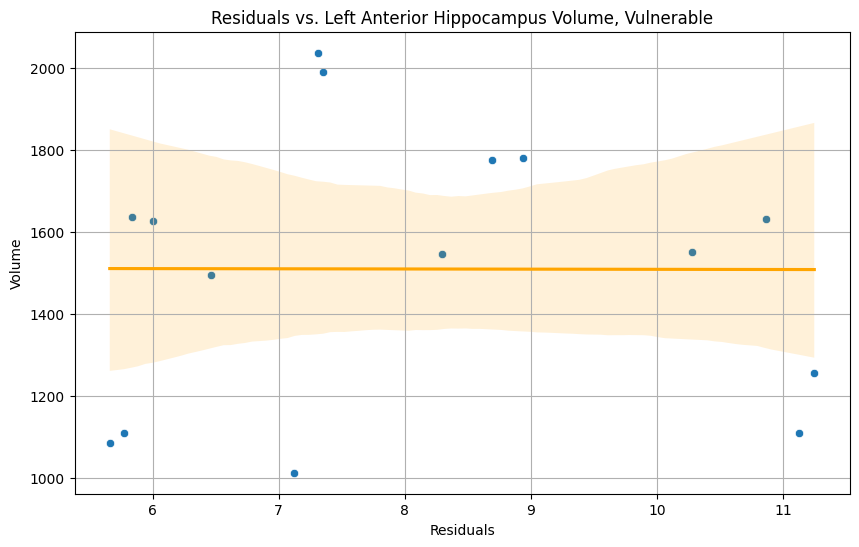

Slope of the regression line: -0.35990610733148143


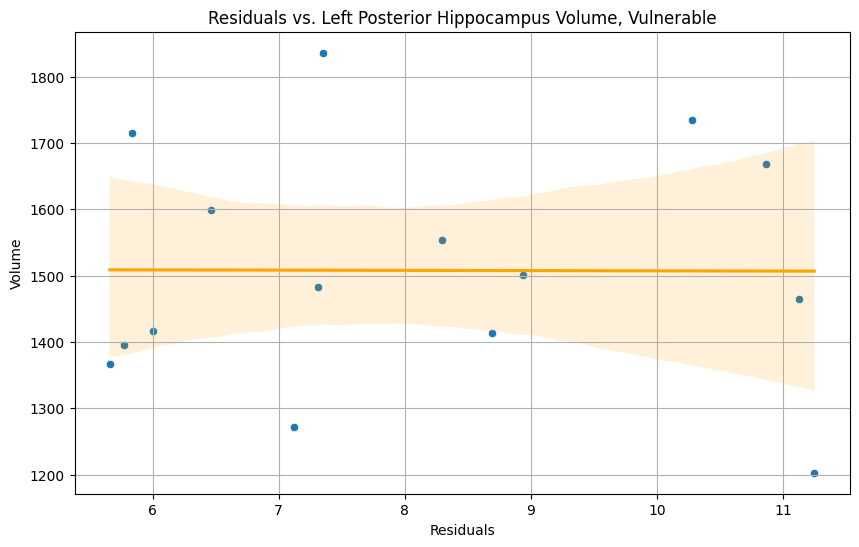

Slope of the regression line: 1.4806214587130981


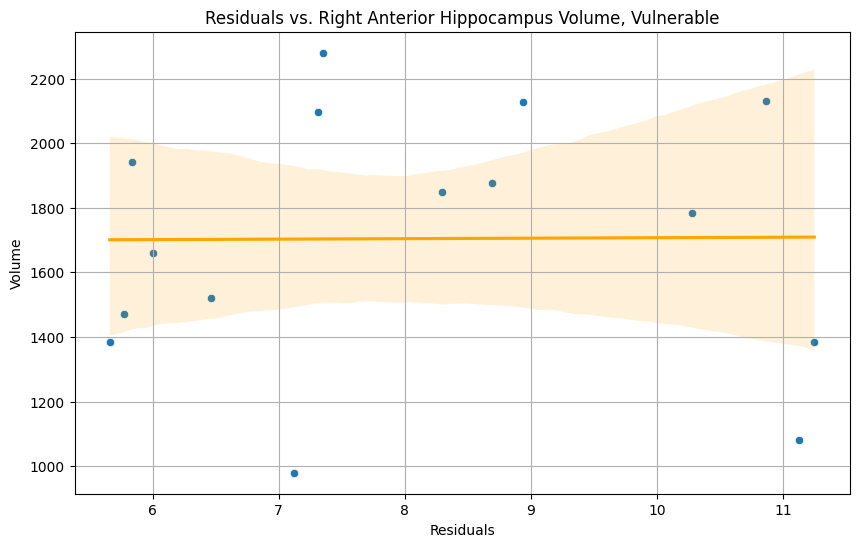

Slope of the regression line: -22.22628894158601


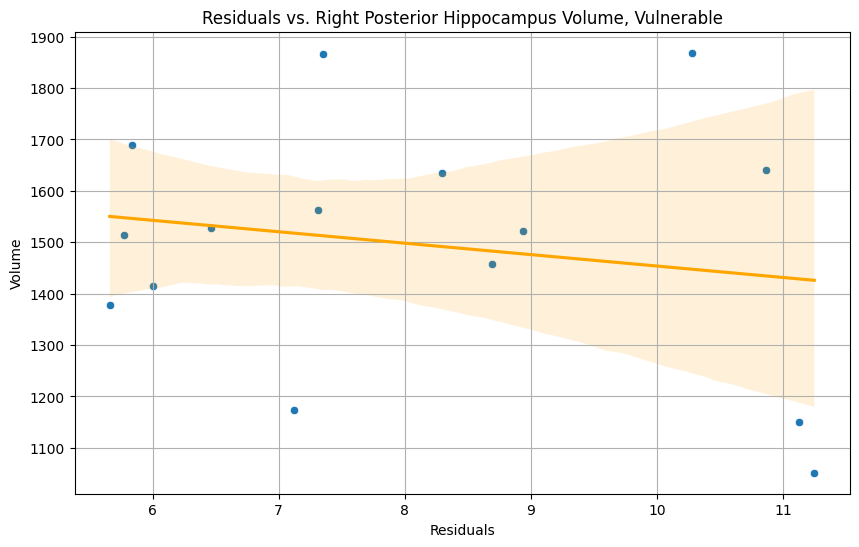

---
Slope of the regression line: 0.015694342009926317


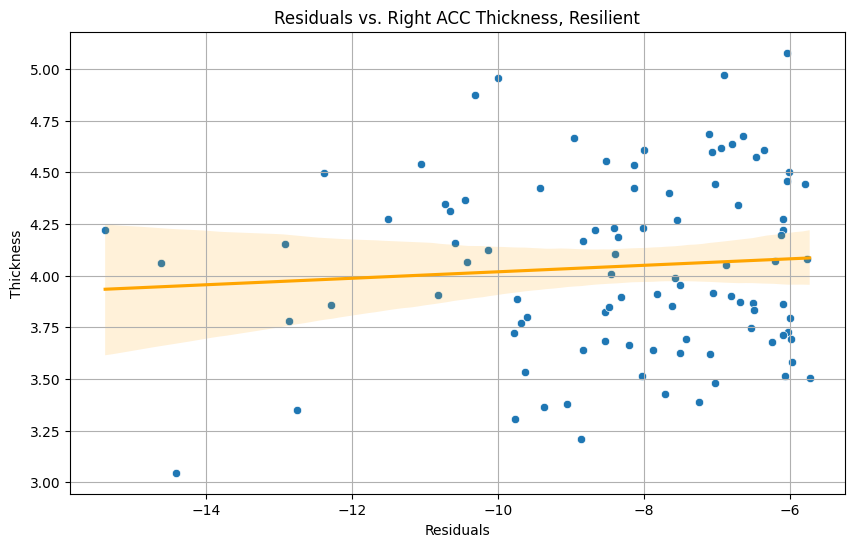

Slope of the regression line: -0.005730996241268262


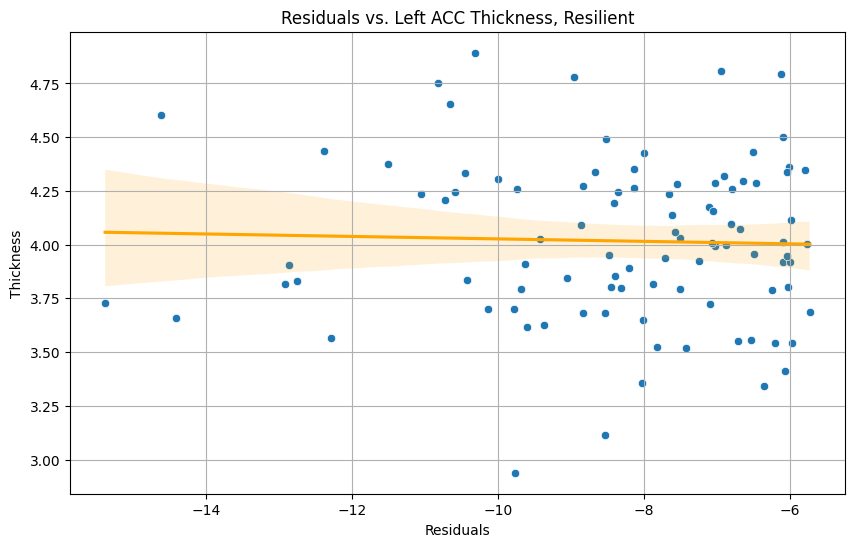

Slope of the regression line: -8.884938002536902


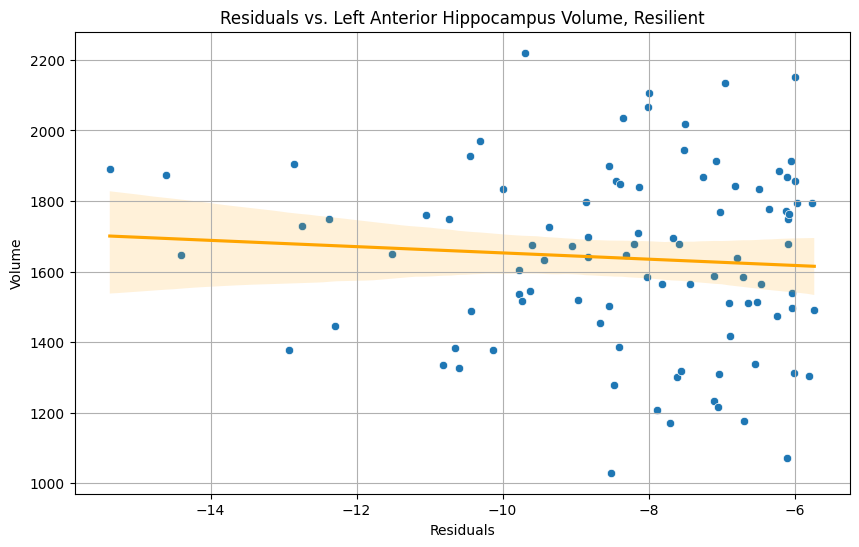

Slope of the regression line: 7.0795132666745975


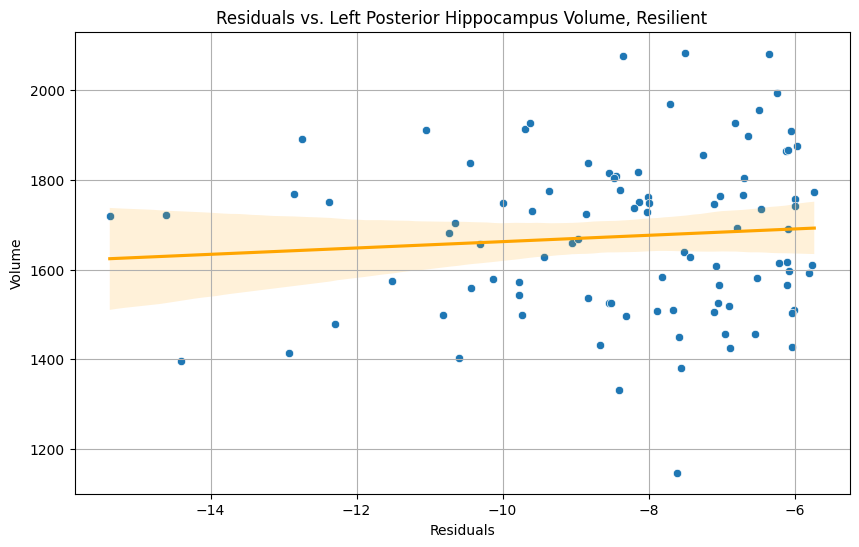

Slope of the regression line: -4.417399968992374


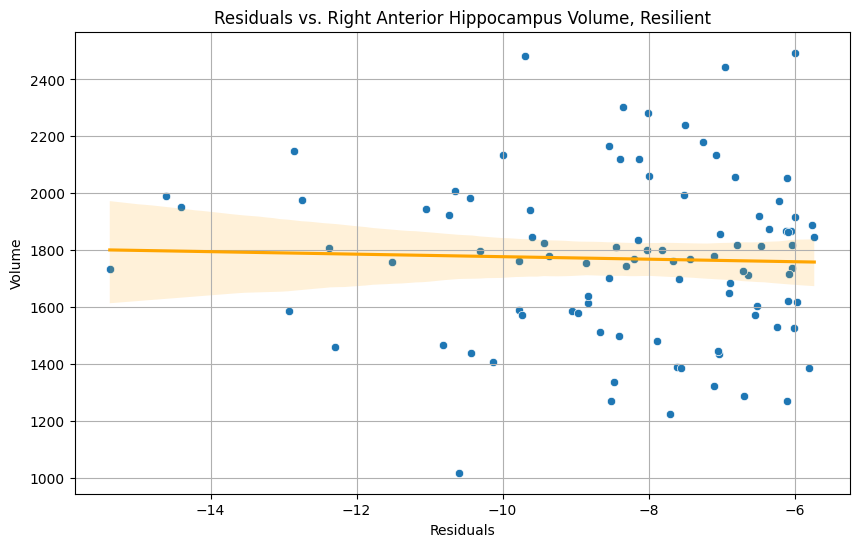

Slope of the regression line: 5.580006786020118


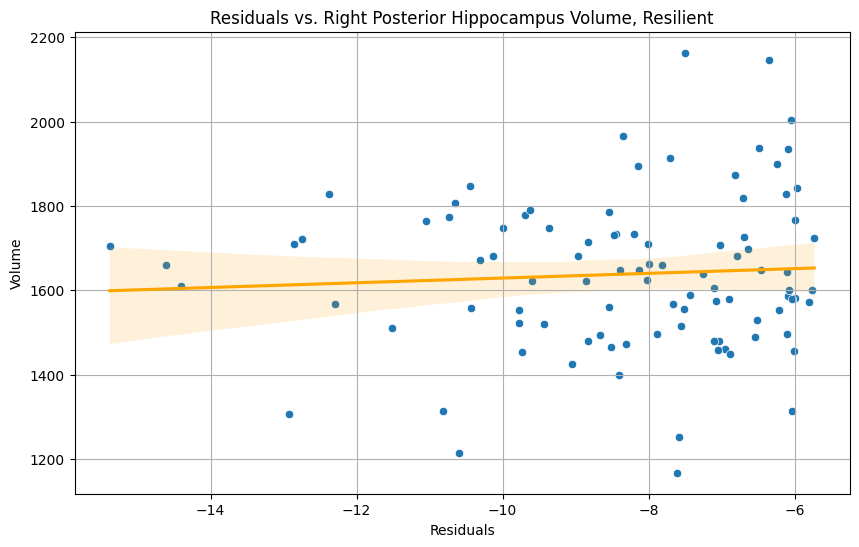

In [ ]:
# Plotting relationship between residuals and regions of interest (raw data)
# Separate plots for vulnerable and resilient groups

# All plots for vulnerable group by region

# Right ACgG
residuals_plot = full_vulner_data['residuals']
Right_ACgG_anterior_cingulate_gyrus_thickness_plot = full_vulner_data['Right_ACgG_anterior_cingulate_gyrus_thickness']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=Right_ACgG_anterior_cingulate_gyrus_thickness_plot, marker='o')
sns.regplot(x=residuals_plot, y=Right_ACgG_anterior_cingulate_gyrus_thickness_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, Right_ACgG_anterior_cingulate_gyrus_thickness_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right ACC Thickness, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Thickness')
plt.grid(True)
plt.show()

# Left ACgG
residuals_plot = full_vulner_data['residuals']
Left_ACgG_anterior_cingulate_gyrus_thickness_plot = full_vulner_data['Left_ACgG_anterior_cingulate_gyrus_thickness']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=Left_ACgG_anterior_cingulate_gyrus_thickness_plot, marker='o')
sns.regplot(x=residuals_plot, y=Left_ACgG_anterior_cingulate_gyrus_thickness_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, Left_ACgG_anterior_cingulate_gyrus_thickness_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left ACC Thickness, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Thickness')
plt.grid(True)
plt.show()

# Left Anterior Hippocampus
residuals_plot = full_vulner_data['residuals']
L_AHippo_VOL_ASHST1_3T_plot = full_vulner_data['L_AHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=L_AHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=L_AHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, L_AHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left Anterior Hippocampus Volume, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Left Posterior Hippocampus
residuals_plot = full_vulner_data['residuals']
L_PHippo_VOL_ASHST1_3T_plot = full_vulner_data['L_PHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=L_PHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=L_PHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, L_PHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left Posterior Hippocampus Volume, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Right Anterior Hippocampus
residuals_plot = full_vulner_data['residuals']
R_AHippo_VOL_ASHST1_3T_plot = full_vulner_data['R_AHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=R_AHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=R_AHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, R_AHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right Anterior Hippocampus Volume, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Right Posterior Hippocampus
residuals_plot = full_vulner_data['residuals']
R_PHippo_VOL_ASHST1_3T_plot = full_vulner_data['R_PHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=R_PHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=R_PHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, R_PHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right Posterior Hippocampus Volume, Vulnerable')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

print('---')

# All plots for resilient group by region

# Right ACgG
residuals_plot = full_resil_data['residuals']
Right_ACgG_anterior_cingulate_gyrus_thickness_plot = full_resil_data['Right_ACgG_anterior_cingulate_gyrus_thickness']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=Right_ACgG_anterior_cingulate_gyrus_thickness_plot, marker='o')
sns.regplot(x=residuals_plot, y=Right_ACgG_anterior_cingulate_gyrus_thickness_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, Right_ACgG_anterior_cingulate_gyrus_thickness_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right ACC Thickness, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Thickness')
plt.grid(True)
plt.show()

# Left ACgG
residuals_plot = full_resil_data['residuals']
Left_ACgG_anterior_cingulate_gyrus_thickness_plot = full_resil_data['Left_ACgG_anterior_cingulate_gyrus_thickness']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=Left_ACgG_anterior_cingulate_gyrus_thickness_plot, marker='o')
sns.regplot(x=residuals_plot, y=Left_ACgG_anterior_cingulate_gyrus_thickness_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, Left_ACgG_anterior_cingulate_gyrus_thickness_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left ACC Thickness, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Thickness')
plt.grid(True)
plt.show()

# Left Anterior Hippocampus
residuals_plot = full_resil_data['residuals']
L_AHippo_VOL_ASHST1_3T_plot = full_resil_data['L_AHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=L_AHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=L_AHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, L_AHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left Anterior Hippocampus Volume, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Left Posterior Hippocampus
residuals_plot = full_resil_data['residuals']
L_PHippo_VOL_ASHST1_3T_plot = full_resil_data['L_PHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=L_PHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=L_PHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, L_PHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Left Posterior Hippocampus Volume, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Right Anterior Hippocampus
residuals_plot = full_resil_data['residuals']
R_AHippo_VOL_ASHST1_3T_plot = full_resil_data['R_AHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=R_AHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=R_AHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, R_AHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right Anterior Hippocampus Volume, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Right Posterior Hippocampus
residuals_plot = full_resil_data['residuals']
R_PHippo_VOL_ASHST1_3T_plot = full_resil_data['R_PHippo_VOL_ASHST1_3T']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=residuals_plot, y=R_PHippo_VOL_ASHST1_3T_plot, marker='o')
sns.regplot(x=residuals_plot, y=R_PHippo_VOL_ASHST1_3T_plot, scatter=False, color='orange')
slope, intercept, r_value, p_value, std_err = stats.linregress(residuals_plot, R_PHippo_VOL_ASHST1_3T_plot)

print("Slope of the regression line:", slope)

plt.title('Residuals vs. Right Posterior Hippocampus Volume, Resilient')
plt.xlabel('Residuals')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

In [ ]:
print(vulnerable.head())
print(thickness_data.head())
print(volume_data.head())
print(full_vulner_data.head())

     INDDID  SEX  HISPANIC  NACCNIHR  EDUC  NACCAGE  UDSBENTC  UDSBENTD  \
0  100085.0    1       0.0         1  11.0       93        16         9   
1  100661.0    1       0.0         1  18.0       86        14         8   
2  102791.0    2       0.0         2  20.0       78        16         4   
3  102962.0    1       0.0         1  18.0       85        13         1   
4  103779.0    2       0.0         1  18.0       88        16         8   

   ANIMALS  VEG  ...  CRAFTDTI  MINTTOTS  MINTTOTW  MINTSCNG  MINTSCNC  \
0       19    8  ...      15.0        31      30.0       1.0       1.0   
1       20   15  ...      21.0        32      31.0       1.0       1.0   
2       10   11  ...      16.0        25      25.0       1.0       0.0   
3       10    5  ...      20.0        17      14.0      18.0       3.0   
4       14   10  ...      20.0        32      32.0       0.0       0.0   

   MINTPCNG  MINTPCNC  ADI2020_STATERNK_v4_0_1  MOCAOR  residuals  
0       1.0       0.0               

['Right_ACgG_anterior_cingulate_gyrus_thickness', 'Left_ACgG_anterior_cingulate_gyrus_thickness', 'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T', 'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T', 'L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness']


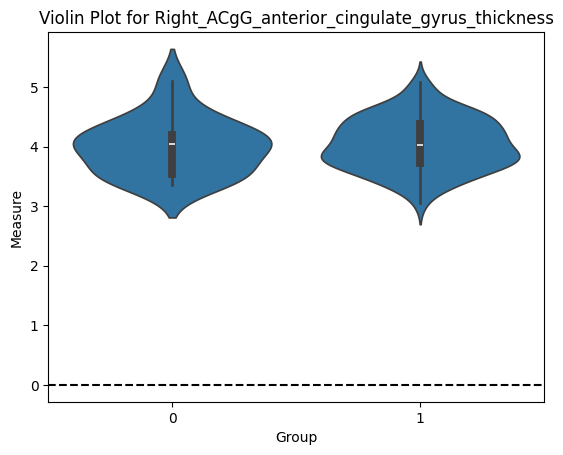

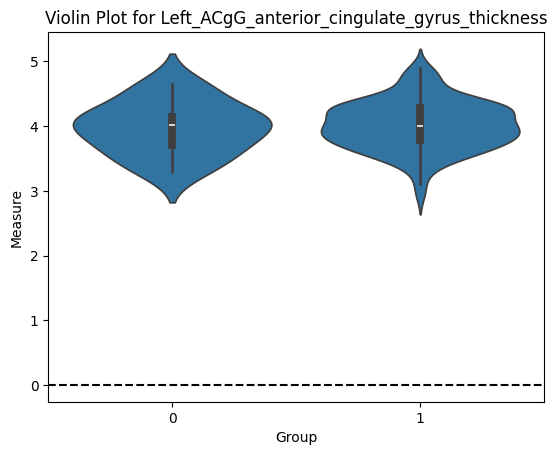

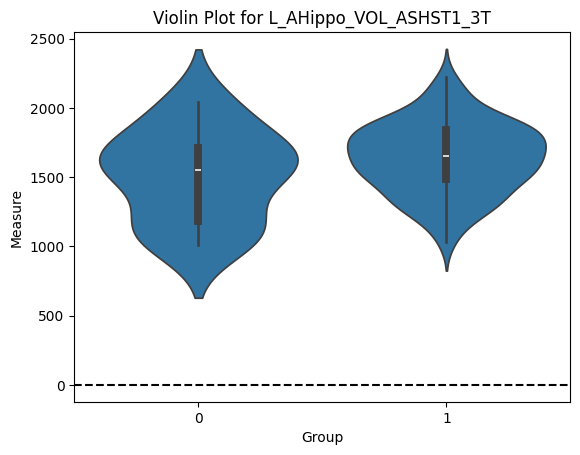

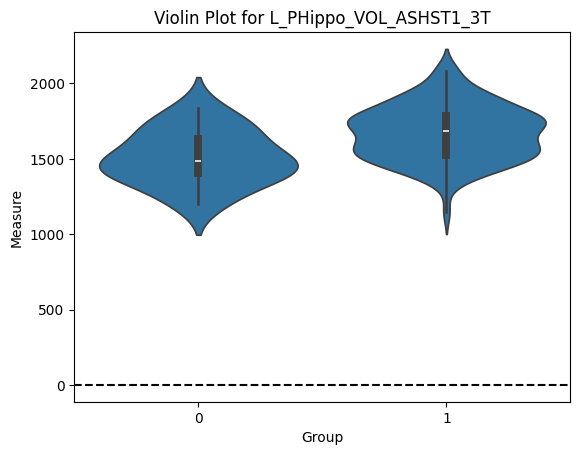

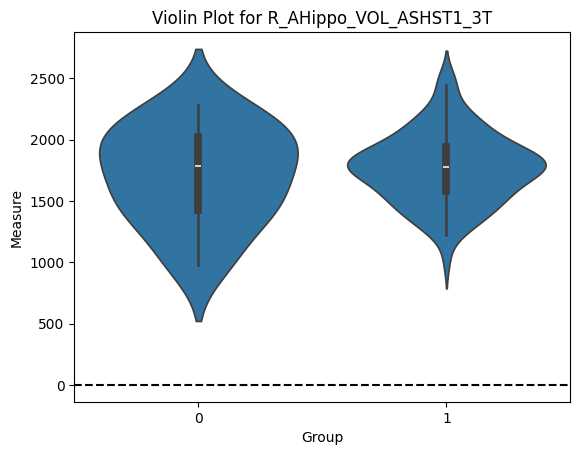

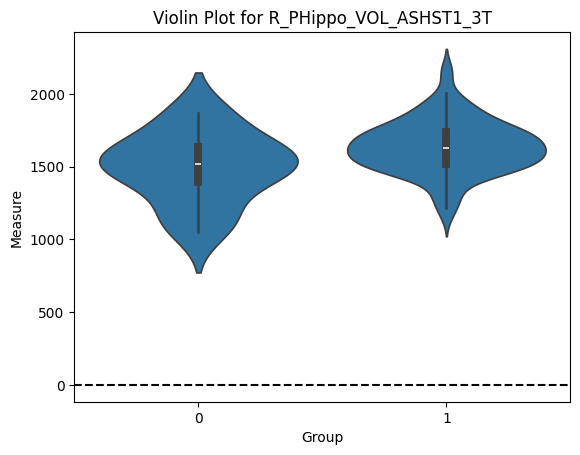

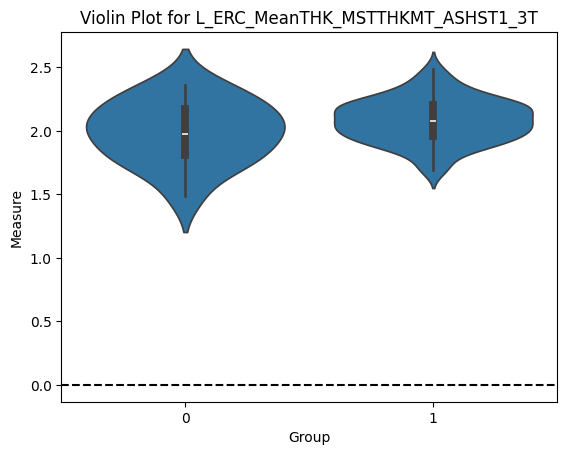

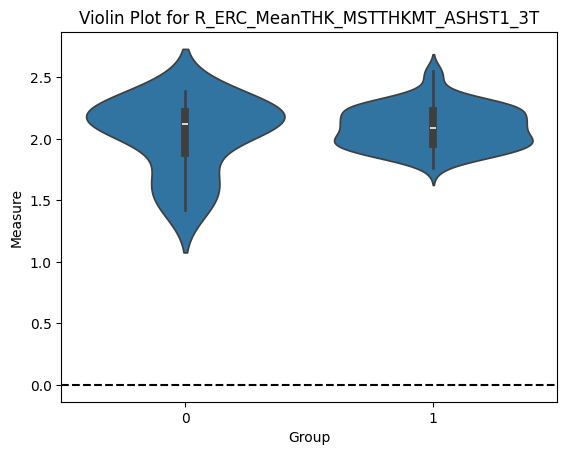

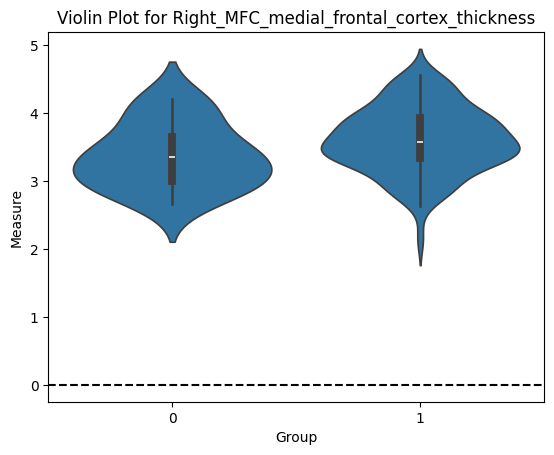

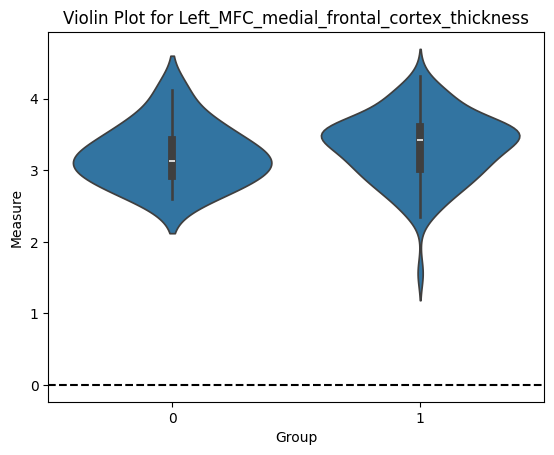

In [ ]:
# Box plots for linear regression results
# Want to have two boxes (one for vulnerable, one for resilient group) on x and volume or thickness on y to see distribution diff btwn groups
# Could also do violin plot or something similar to ADI analysis plot where each violin is one of the two groups...and y is thickness/vol or is y residuals?
  # Y in violin plot should be thickness/volume, bc relationship btwn group and residuals doesn't tell you much here since residuals define the groups

# Combining primary and secondary superager regions of interest to loop through all
combined_superager_regions = superager_regions + superager_secondary_regions
print(combined_superager_regions)

# Creating violin plot comparing means of superagers vs normal groups for ROI thickness/volume measures
import seaborn as sns
import matplotlib.pyplot as plt

for region in combined_superager_regions:

  ## Pull Group from combined resil and vulner dataframe (0 is vulnerable and 1 is resilient)
  data_for_plot = {'Group': df_combined['Group'],
                 'Measure': df_combined[region]}

  ## Visualize plot
  penn_violin_plot = sns.violinplot(x='Group', y='Measure', data=data_for_plot, inner='box', density_norm='width')
  plt.xlabel("Group")
  plt.ylabel("Measure")
  plt.title(f"Violin Plot for {region}")

  ## Add x-axis at y=0
  penn_violin_plot.axhline(y=0, color='black', linestyle='--')
  plt.show()

## Superagers using percentile scoring: quartiles
Identifying resilient and vulnerable groups as individuals with a percentile rank of <25 (resilient) or >75 (vulnerable) based on the distribution of their corresponding age group in the test data. Groups will be used in the same way as above stratified superager vs. vulnerable analysis.

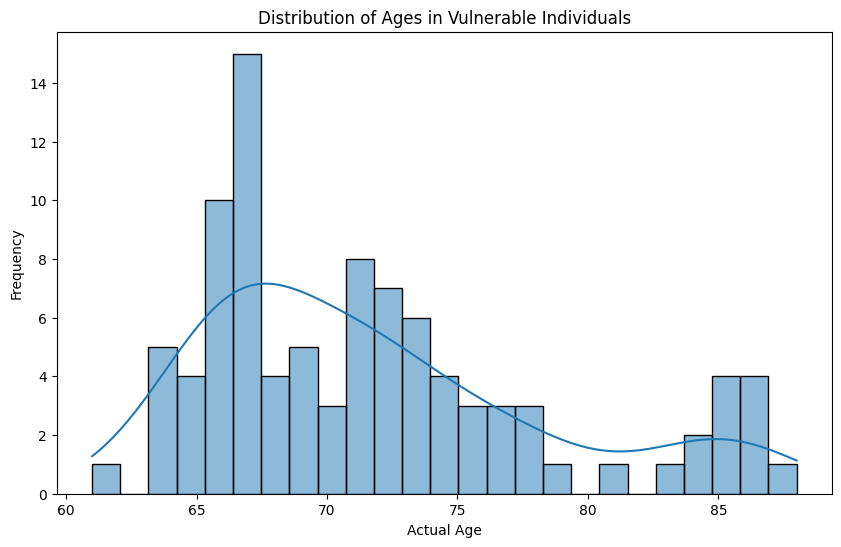

         INDDID  ADI2020_STATERNK_v4_0_1   TESTDATE  SEX  HISPANIC  NACCNIHR  \
17    100661.00                        6 2015-12-22    1         0         1   
116   102791.00                        7 2017-08-11    2         0         2   
120   102962.00                        1 2015-06-02    1         0         1   
121   103779.00                        1 2017-06-23    2         0         1   
142   104489.01                        2 2015-04-01    1         0         1   
...         ...                      ...        ...  ...       ...       ...   
1755  130833.00                        4 2023-10-10    1         0         2   
1770  131211.00                        1 2024-01-24    2         0         2   
1771  131219.00                        8 2024-02-29    2         0         2   
1772  131241.00                        5 2024-02-08    2         0         2   
1774  131330.00                        5 2024-02-19    1         0         2   

      EDUC  NACCAGE  UDSBENTC  UDSBENTD

In [ ]:
# Dividing penn_only_data into vulnerable and resilient groups based on quartiles
# Percentile ranks currently not whole numbers, but shouldn't matter for thresholding

resilient_quart = penn_only_data[penn_only_data['percentile_rank'] <= 25]
vulnerable_quart = penn_only_data[penn_only_data['percentile_rank'] >= 75]

print(len(resilient_quart))
print(len(vulnerable_quart))

# Checking actual age distributions of resilient group
plt.figure(figsize=(10, 6))
sns.histplot(resilient_quart['NACCAGE'], bins=25, kde=True)
plt.title('Distribution of Ages in Resilient Individuals')
plt.xlabel('Actual Age')
plt.ylabel('Frequency')
plt.show()
#print(resilient_quart)

# Checking actual age distribution of vulnerable group
plt.figure(figsize=(10, 6))
sns.histplot(vulnerable_quart['NACCAGE'], bins=25, kde=True)
plt.title('Distribution of Ages in Vulnerable Individuals')
plt.xlabel('Actual Age')
plt.ylabel('Frequency')
plt.show()
#print(vulnerable_quart)

In [ ]:
# Save dataframes of vulnerable and resilient individuals using quartiles to csv file
vul_save_path = '/content/drive/Shareddrives/Cognitive Age Project/vulnerable_indiv_percent_quartile.csv'
vulnerable_quart.to_csv(vul_save_path, index=False)
resil_save_path = '/content/drive/Shareddrives/Cognitive Age Project/resilient_indiv_percent_quartile.csv'
resilient_quart.to_csv(resil_save_path, index=False)

In [ ]:
# Merging in volume and thickness tables to do group comparison between resilient and vulnerable for regions of interest
# Could do just 80+ for true superager analysis, but will use resilient and vulnerable of all ages right now for power

# Import and merge in thickness and volume measures
thickness_path = '/content/drive/Shareddrives/Cognitive Age Project/ABC_3T_thickness_20240715.csv'
thickness_data = pd.read_csv(thickness_path)
thickness_data = thickness_data.rename(columns = {'INDD' : 'INDDID'})
thickness_data['INDDID'] = thickness_data['INDDID'].astype(float)
#penn_only_data['INDDID'] = penn_only_data['INDDID'].astype(float)

# Include only one scan for each individual
# Ensure this scan is closest in date to the cognitive test date (TESTDATE)
thickness_data['MRIDATE'] = pd.to_datetime(thickness_data['MRIDATE'], format='%Y%m%d', errors='coerce')
# Start by adding in 'TESTDATE' for each indiv into all thickness_data rows for that indiv
penn_only_data['TESTDATE'] = pd.to_datetime(penn_only_data['TESTDATE'], format='%Y-%m-%d', errors='coerce')
thickness_data = pd.merge(thickness_data, penn_only_data[['INDDID', 'TESTDATE']], on='INDDID', how='left')
thickness_data = thickness_data.dropna(subset=['MRIDATE', 'TESTDATE'])

# Calculate the absolute difference between MRIDATE and TESTDATE for every scan row
thickness_data['MRI_Cog_test_distance'] = abs(thickness_data['MRIDATE'] - thickness_data['TESTDATE'])

# Sort by INDDID and MRI_Cog_test_distance, then keep the row with the smallest difference
thickness_data = thickness_data.sort_values(by=['INDDID', 'MRI_Cog_test_distance']).drop_duplicates(subset='INDDID', keep='first')

# Display the first few rows to verify it's loaded correctly
print(thickness_data.head())
print(len(thickness_data))



# Import volume
volume_path = '/content/drive/Shareddrives/Cognitive Age Project/ABC_MRI3T_ASHST1T2_measurements_20240712.csv'
volume_data = pd.read_csv(volume_path)
volume_data = volume_data.rename(columns = {'ID' : 'INDDID'})
volume_data['INDDID'] = volume_data['INDDID'].astype(float)
print(type(volume_data['INDDID'][0]))

# Include only the closest scan to cognitive testing for each individual
volume_data['SCANDATE'] = pd.to_datetime(volume_data['SCANDATE'], format='%Y%m%d', errors='coerce')
volume_data = pd.merge(volume_data, penn_only_data[['INDDID', 'TESTDATE']], on='INDDID', how='left')
volume_data = volume_data.dropna(subset=['SCANDATE', 'TESTDATE'])

# Calculate the absolute difference between MRIDATE and TESTDATE for every scan row
volume_data['Scan_Cog_test_distance'] = abs(volume_data['SCANDATE'] - volume_data['TESTDATE'])

# Sort by INDDID and Scan_Cog_test_distance, then keep the row with the smallest difference
volume_data = volume_data.sort_values(by=['INDDID', 'Scan_Cog_test_distance']).drop_duplicates(subset='INDDID', keep='first')

# Display the first few rows to verify it's loaded correctly
print(volume_data.head())
print(len(volume_data))



#Using new group assignments (quartiles)
full_vulner_data_quart = pd.merge(vulnerable_quart, thickness_data, on='INDDID')
full_vulner_data_quart = pd.merge(full_vulner_data_quart, volume_data, on='INDDID')
print(full_vulner_data_quart.head())
print(len(full_vulner_data_quart))

full_resil_data_quart = pd.merge(resilient_quart, thickness_data, on='INDDID')
full_resil_data_quart = pd.merge(full_resil_data_quart, volume_data, on='INDDID')
print(full_resil_data_quart.head())
print(len(full_resil_data_quart))

     INDDID  ADI2020_STATERNK_v4_0_1 TESTDATE_x  SEX  HISPANIC  NACCNIHR  \
0  107476.0                        1 2015-06-29    2         0         1   
1  107973.0                        4 2016-09-28    2         0         1   
2  109789.0                        4 2015-07-06    1         0         1   
3  111487.0                        1 2015-11-19    1         0         1   
4  115562.0                        7 2016-12-20    1         0         1   

   EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  M_DG_VOL_ASHST2_3T  \
0  18.0     67.0      16.0       7.0  ...            560.0875   
1  16.0     66.0      16.0       6.0  ...            573.7955   
2  12.0     69.0      16.0       7.0  ...            470.2510   
3  16.0     66.0      16.0      13.0  ...            559.7490   
4  18.0     86.0      15.0      13.0  ...            417.0755   

   M_CA3_VOL_ASHST2_3T  M_Tail_VOL_ASHST2_3T  M_SUB_VOL_ASHST2_3T  \
0             163.1250              530.3495            1121.2405   
1             

In [ ]:
# Adding AgeAtScan column to use as covariate in linear regression: NACCAGE + MRI_Cog_test_distance (in years)
# First, calculate the days difference between the dates
full_vulner_data_quart['difference_days'] = (full_vulner_data_quart['MRIDATE'] - full_vulner_data_quart['TESTDATE']).dt.days

# Convert positive differences into years and add to 'Age', leaving negatives unchanged
full_vulner_data_quart['AgeAtScan'] = full_vulner_data_quart['NACCAGE'] + full_vulner_data_quart['difference_days'].apply(lambda x: x // 365 if x > 0 else 0)
print(full_vulner_data_quart.head())


# Doing same conversion for resilient dataset
full_resil_data_quart['difference_days'] = (full_resil_data_quart['MRIDATE'] - full_resil_data_quart['TESTDATE']).dt.days

# Convert positive differences into years and add to 'Age', leaving negatives unchanged
full_resil_data_quart['AgeAtScan'] = full_resil_data_quart['NACCAGE'] + full_resil_data_quart['difference_days'].apply(lambda x: x // 365 if x > 0 else 0)
print(full_resil_data_quart.head())

     INDDID  ADI2020_STATERNK_v4_0_1 TESTDATE_x  SEX  HISPANIC  NACCNIHR  \
0  107476.0                        1 2015-06-29    2         0         1   
1  107973.0                        4 2016-09-28    2         0         1   
2  109789.0                        4 2015-07-06    1         0         1   
3  111487.0                        1 2015-11-19    1         0         1   
4  115562.0                        7 2016-12-20    1         0         1   

   EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  M_Tail_VOL_ASHST2_3T  \
0  18.0     67.0      16.0       7.0  ...              530.3495   
1  16.0     66.0      16.0       6.0  ...              385.3070   
2  12.0     69.0      16.0       7.0  ...              265.1030   
3  16.0     66.0      16.0      13.0  ...              448.0705   
4  18.0     86.0      15.0      13.0  ...              330.4835   

   M_SUB_VOL_ASHST2_3T  M_ERC_VOL_ASHST2_3T  M_BA35_VOL_ASHST2_3T  \
0            1121.2405             927.7960              647.8495   
1 

In [ ]:
# Save full df of vulnerable and resilient individuals (quartiles) with vol/thickness measures to csv file
vul_save_path = '/content/drive/Shareddrives/Cognitive Age Project/vulnerable_thickness_volume_quart.csv'
full_vulner_data_quart.to_csv(vul_save_path, index=False)
resil_save_path = '/content/drive/Shareddrives/Cognitive Age Project/resilient_thickness_volume_quart.csv'
full_resil_data_quart.to_csv(resil_save_path, index=False)

In [ ]:
# Temporarily fixing missing data (dropping rows)
full_vulner_data_quart = full_vulner_data_quart.dropna(subset=['Right_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'Left_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                                                   'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T',
                                                   'L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'])
full_resil_data_quart = full_resil_data_quart.dropna(subset=['Right_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'Left_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                                                   'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T',
                                                   'L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'])
print(len(full_vulner_data_quart))
print(len(full_resil_data_quart))

59
75


In [ ]:
# Checking normality of vulnerable and resilient data
# Based on whether percentile scores are normally distributed within each group or not

import numpy as np
from scipy.stats import shapiro

# Perform the Shapiro-Wilk test on percentiles from vulnerable data
statistic, p_value = shapiro(full_vulner_data_quart['percentile_rank'])

# Print the results
print("Shapiro-Wilk statistic for vulnerable data:", statistic)
print("p-value:", p_value)

# Interpret the results
if p_value > 0.05:
    print("Data is likely normally distributed.")
else:
    print("Data is likely not normally distributed.")


# Perform the Shapiro-Wilk test on percentiles from resilient data
statistic, p_value = shapiro(full_vulner_data_quart['percentile_rank'])

# Print the results
print("Shapiro-Wilk statistic for resilient data:", statistic)
print("p-value:", p_value)

# Interpret the results
if p_value > 0.05:
    print("Data is likely normally distributed.")
else:
    print("Data is likely not normally distributed.")

Shapiro-Wilk statistic for vulnerable data: 0.893822483643314
p-value: 8.992648605231075e-05
Data is likely not normally distributed.
Shapiro-Wilk statistic for resilient data: 0.893822483643314
p-value: 8.992648605231075e-05
Data is likely not normally distributed.


In [ ]:
# Mann-Whitney U test to test for significant difference between vulnerable and resilient population by ROI
# Data is not normally distributed, so using non-parametric test

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# List regions of interest
superager_regions = ['Right_ACgG_anterior_cingulate_gyrus_thickness', 'Left_ACgG_anterior_cingulate_gyrus_thickness',
                    'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                     'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T']
superager_secondary_regions = ['L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness']
combined_superager_regions = superager_regions + superager_secondary_regions

# Add a column to each df (vulnerable and resilient) indicating the group
full_vulner_data_quart['Group'] = 0
full_resil_data_quart['Group'] = 1

# Combine vulnerable and resilient data
df_combined_quart = pd.concat([full_vulner_data_quart, full_resil_data_quart])
print(df_combined_quart)

#combined_path = '/content/drive/Shareddrives/Cognitive Age Project/full_df_combined_quart.csv'
#df_combined_quart.to_csv(combined_path, index=False)

# Separate the data by groups
vul_0 = df_combined_quart[df_combined_quart['Group'] == 0]
resil_1 = df_combined_quart[df_combined_quart['Group'] == 1]

# Store results
results = []

# Create list of just p-values for significance bar plotting
p_values = []

# Perform Mann-Whitney U test for each region
for region in combined_superager_regions:
    u_stat, p_value = mannwhitneyu(vul_0[region], resil_1[region], alternative='two-sided')
    results.append({'region': region, 'u_stat': u_stat, 'p_value': p_value})
    p_values.append(p_value)

# Convert results to a DataFrame for easier interpretation
results_df = pd.DataFrame(results)

# Saving results_df
results_path = '/content/drive/Shareddrives/Cognitive Age Project/mann_whitney_results_quart.csv'
#results_df.to_csv(results_path, index=False)

# Print results
print(results_df)


      INDDID  ADI2020_STATERNK_v4_0_1 TESTDATE_x  SEX  HISPANIC  NACCNIHR  \
0   107476.0                        1 2015-06-29    2         0         1   
1   107973.0                        4 2016-09-28    2         0         1   
2   109789.0                        4 2015-07-06    1         0         1   
3   111487.0                        1 2015-11-19    1         0         1   
4   115562.0                        7 2016-12-20    1         0         1   
..       ...                      ...        ...  ...       ...       ...   
70  129860.0                        5 2023-02-06    2         0         2   
71  130486.0                        1 2023-06-29    2         1        99   
72  130640.0                       10 2023-08-29    2         0         2   
73  130847.0                        1 2023-10-23    1         0         2   
74  131182.0                        3 2024-02-21    2         0         2   

    EDUC  NACCAGE  UDSBENTC  UDSBENTD  ...  M_SUB_VOL_ASHST2_3T  \
0   18.0

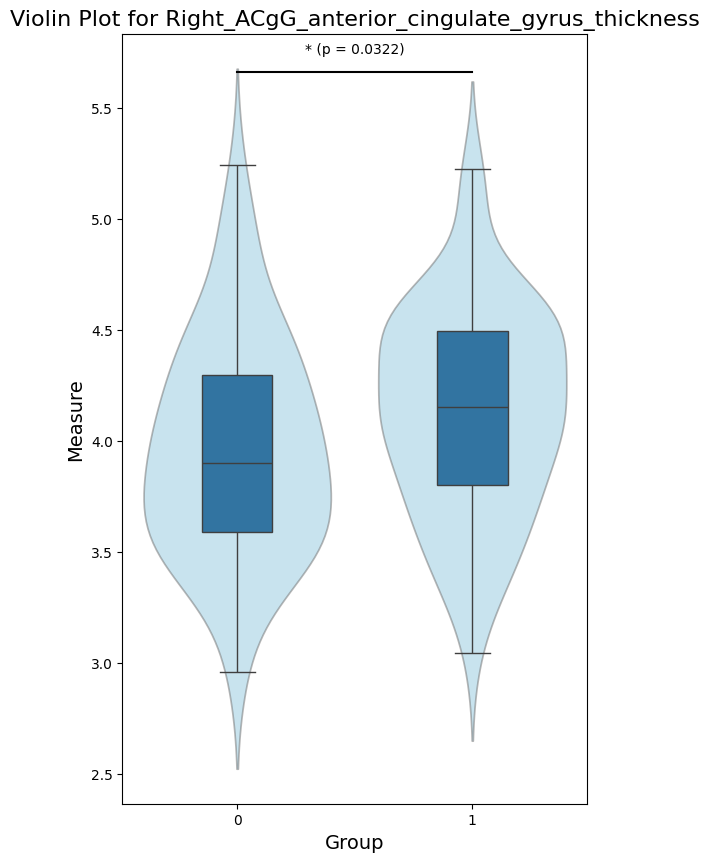

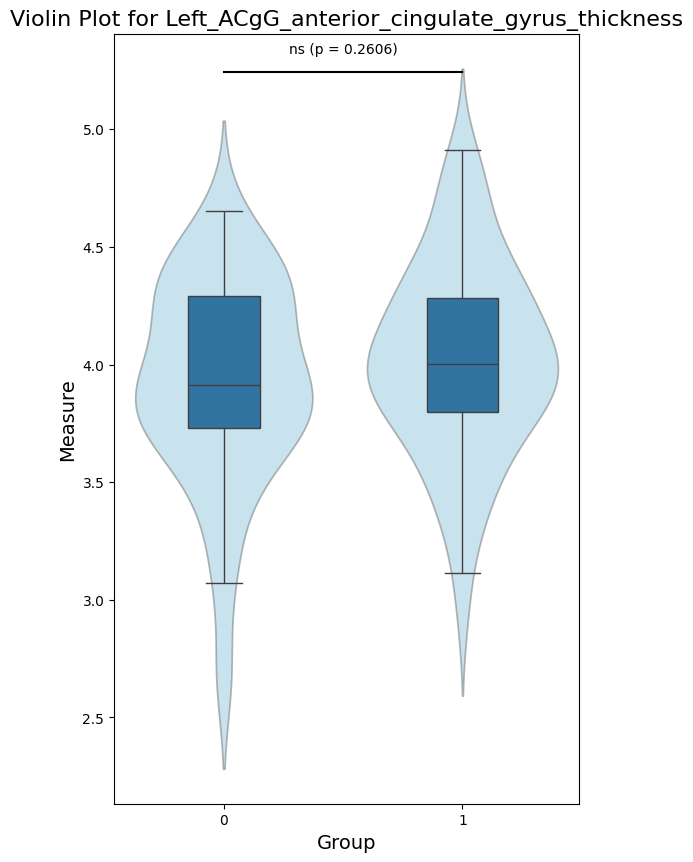

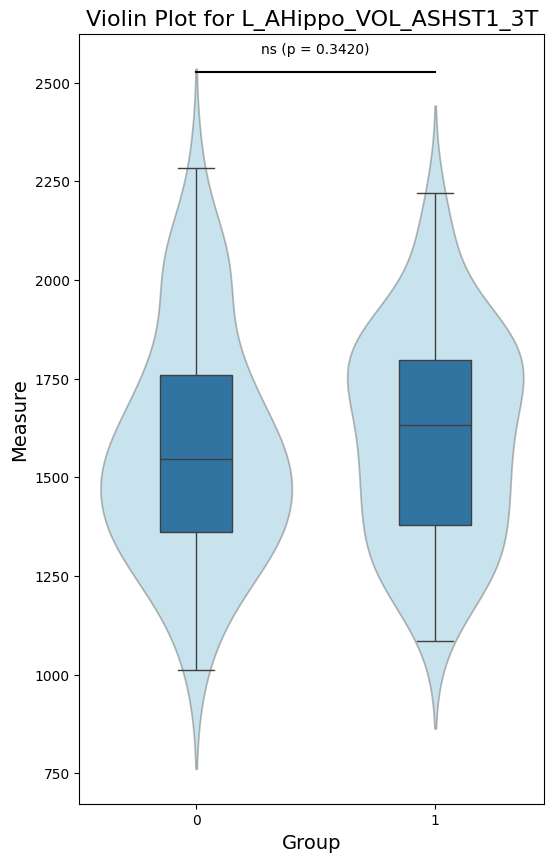

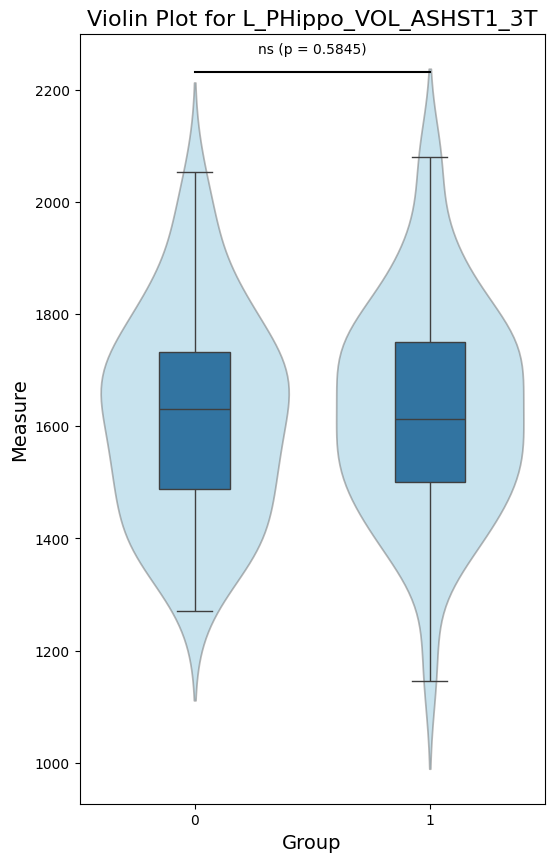

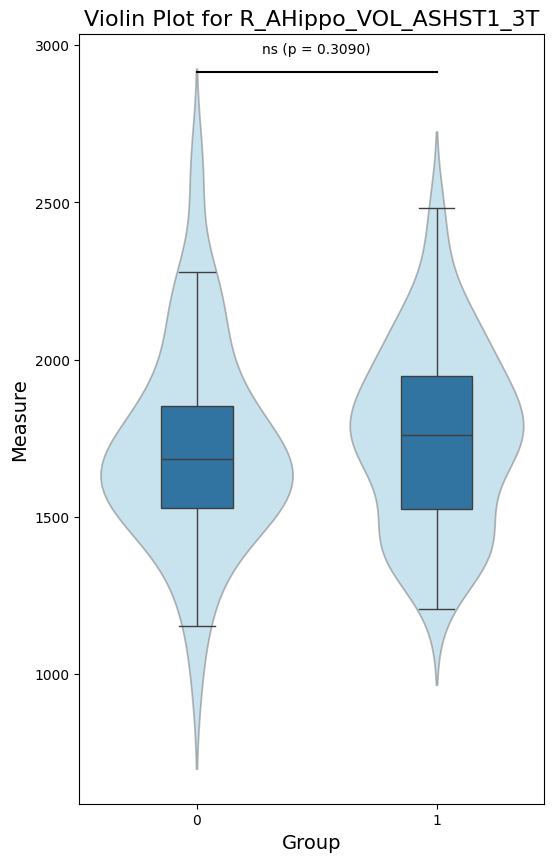

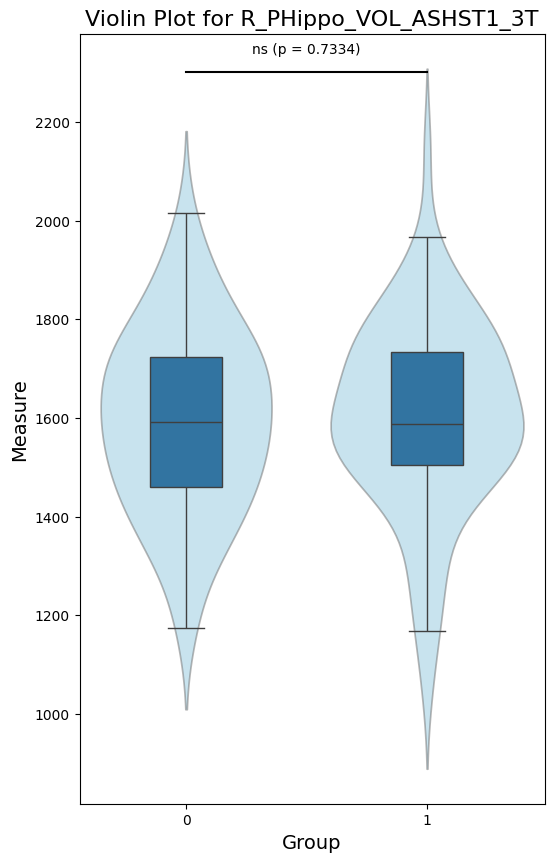

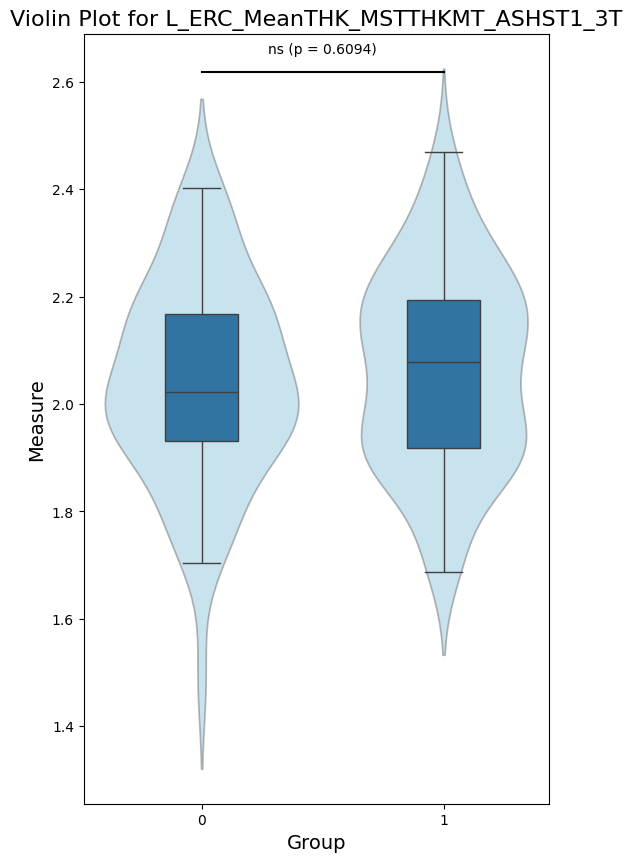

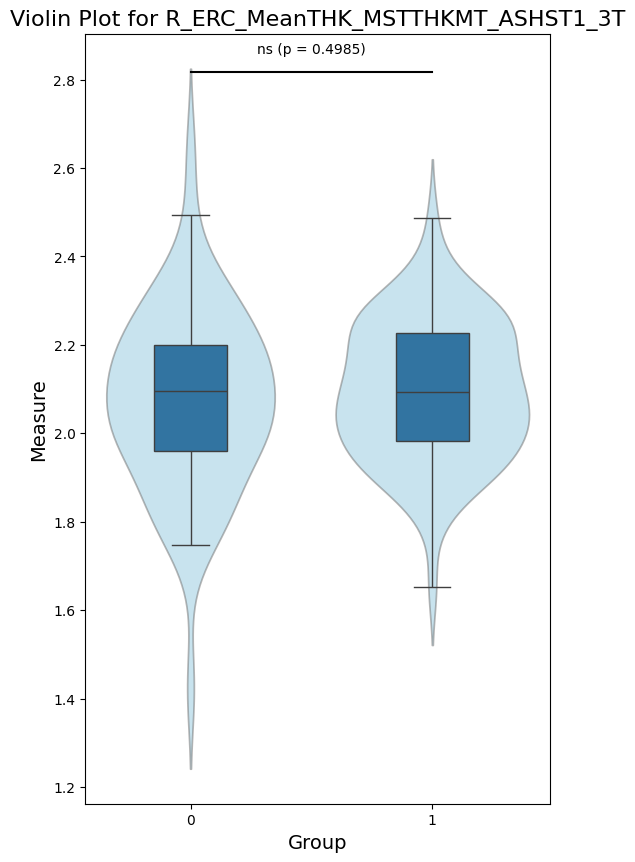

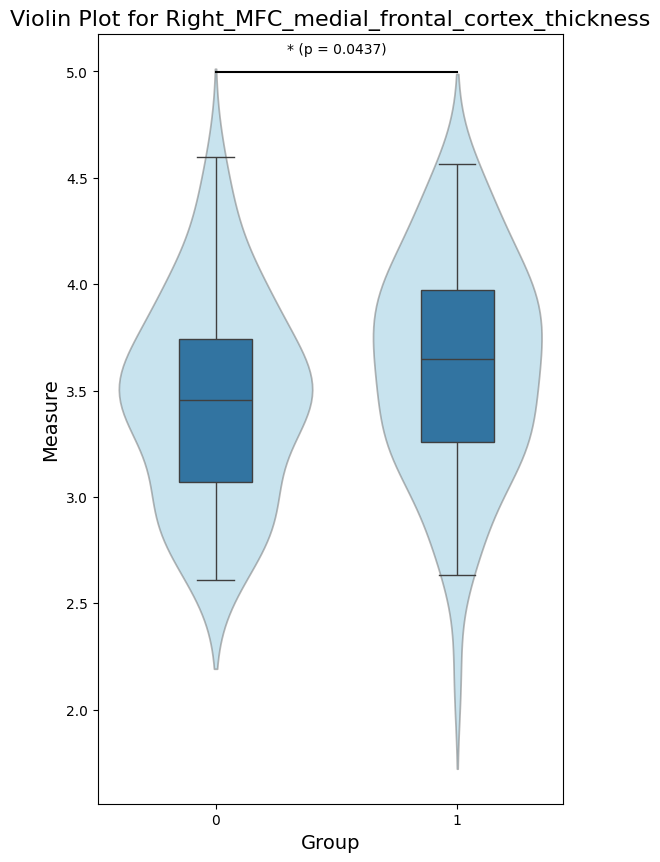

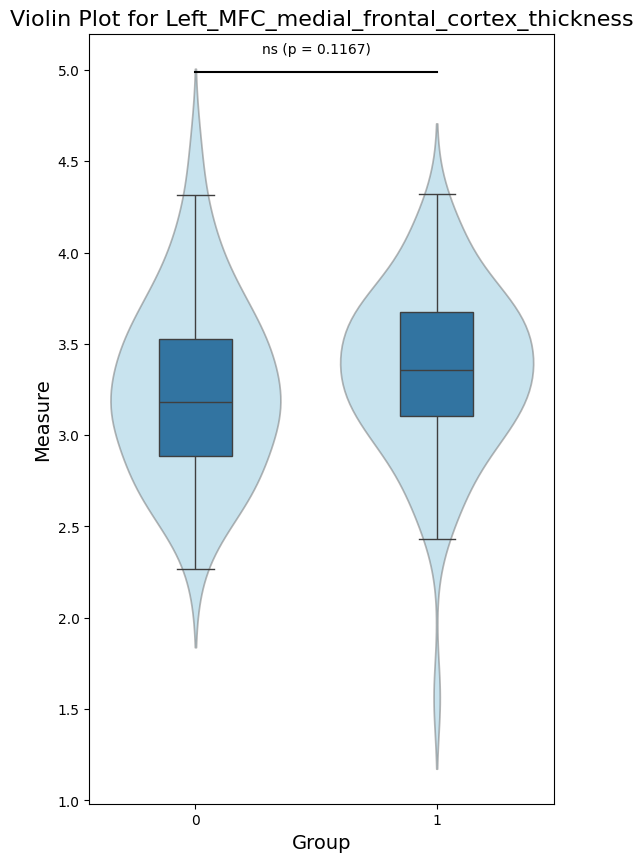

In [ ]:
# Violin plots for Mann-Whitney U Test results
# Want to have two violins (one for vulnerable, one for resilient group) on x and volume or thickness on y to see distribution diff btwn groups


# Creating violin plot comparing means of superagers vs normal groups for ROI thickness/volume measures
import seaborn as sns
import matplotlib.pyplot as plt


# ADD SIGNIF STARS
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

for region in combined_superager_regions:

  # Index region in list to pull associated p-value for significance bar plotting
  p_value_index = combined_superager_regions.index(region)
  p_value = p_values[p_value_index]

  # Pull Group from combined resil and vulner dataframe (0 is vulnerable and 1 is resilient)
  data_for_plot = {'Group': df_combined_quart['Group'],
                 'Measure': df_combined_quart[region]}

  # Format the p-value to 4 decimal places
  p_value_text = f"p = {p_value:.4f}"

  # Run p-value to asterisk function for p-value
  asterisks = convert_pvalue_to_asterisks(p_value)

  # Combine the significance and p-value
  annotation_text = f"{asterisks} ({p_value_text})"

  plt.figure(figsize=(6, 10))

  # Violin plot (semi-transparent)
  sns.violinplot(
      data=data_for_plot,
      x='Group',
      y='Measure',
      inner=None,  # Turn off internal marks to avoid overlap with the boxplot
      color='skyblue',
      alpha=0.5
  )

  # Box plot (overlaid)
  sns.boxplot(
      data=data_for_plot,
      x='Group',
      y='Measure',
      width=0.3,  # Narrow width to fit within the violin plot
      showfliers=False,  # Hide outlier points to avoid redundancy
      boxprops={'zorder': 2}  # Ensure the box plot is on top
  )


  # Customize the plot
  plt.title(f"Violin Plot for {region}", fontsize=16)
  plt.xlabel("Group", fontsize=14)
  plt.ylabel("Measure", fontsize=14)
  #plt.grid(axis='y', linestyle='--', alpha=0.7)
  #plt.tight_layout()


  # Add the asterisk above the plot
  x1, x2 = 0, 1   # x-coordinates of the groups
  y, h, col = data_for_plot['Measure'].max() + 0.2, 0.02, 'k'  # y position of the line and a little space above the max


  # Add a line and annotation relative to the top of the figure
  ax = plt.gca()  # Get the current axis

  # Position annotation and line relative to the axes (normalized coordinates)
  y_line_position = 0.95  # Line position as a fraction of the figure height
  y_text_position = 0.97  # Text position slightly above the line

  # Add the horizontal line between the two groups using normalized coordinates
  ax.plot([x1, x2], [y_line_position, y_line_position], lw=1.5, c=col, transform=ax.get_xaxis_transform())

  # Add the annotation with significance and p-value
  ax.text((x1 + x2) * 0.5, y_text_position, annotation_text, ha='center', va='bottom', color=col, transform=ax.get_xaxis_transform())


  # Show the plot
  plt.show()




## Superagers using percentile scoring: continuous
Using full Penn data (whole spectrum from resilient to continuous) to see whether there is a significant trend in regional thickness or volume as you go from 0-99th percentile.

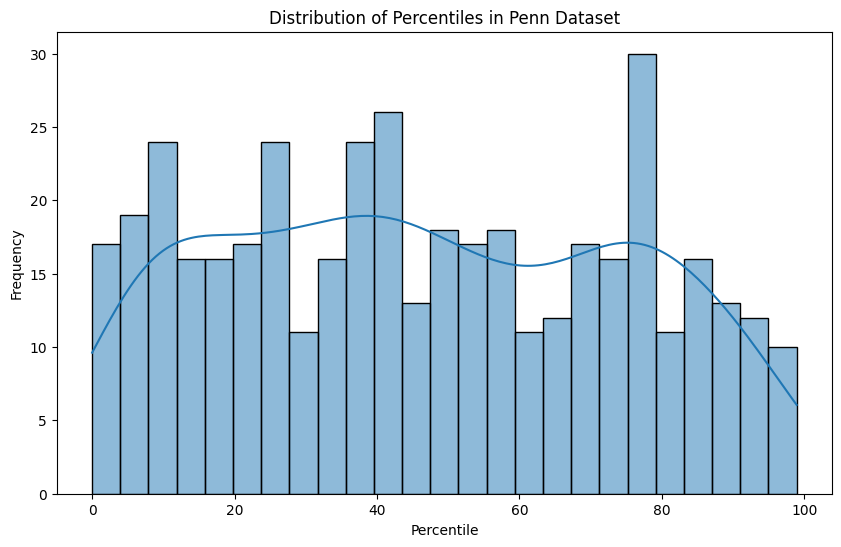

In [ ]:
# Checking percentile distribution of full Penn data
plt.figure(figsize=(10, 6))
sns.histplot(penn_only_data['percentile_rank'], bins=25, kde=True)
plt.title('Distribution of Percentiles in Penn Dataset')
plt.xlabel('Percentile')
plt.ylabel('Frequency')
plt.show()

277
Linear regression results for Right_ACgG_anterior_cingulate_gyrus_thickness, full data:
Slope of the regression line: -0.0018438742669587601


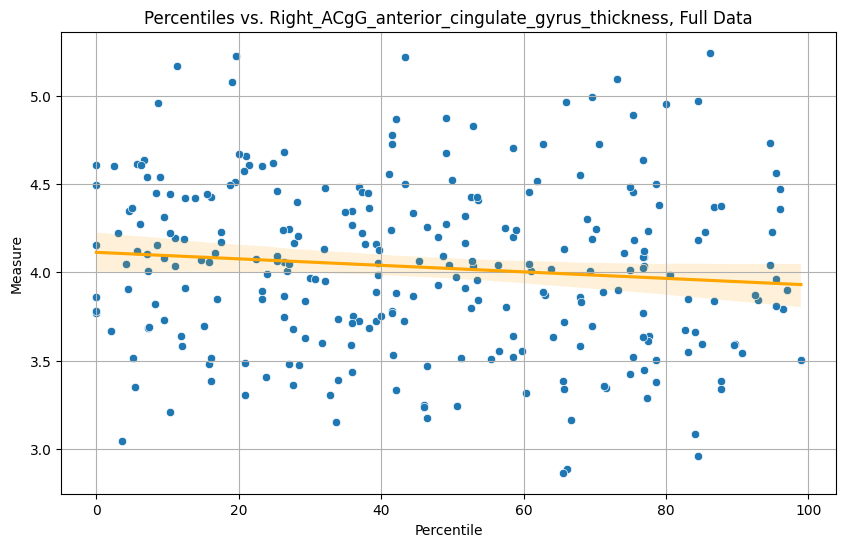

Linear regression results for Left_ACgG_anterior_cingulate_gyrus_thickness, full data:
Slope of the regression line: -0.0011721505461162623


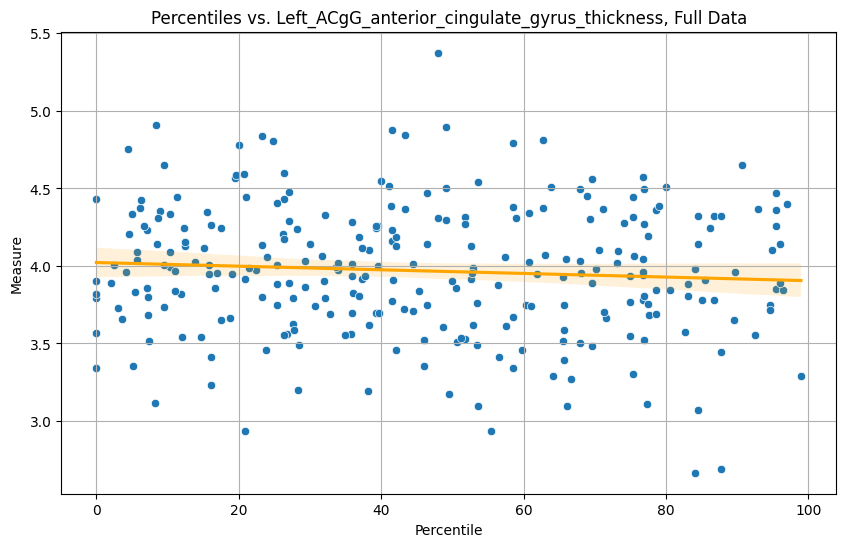

Linear regression results for L_AHippo_VOL_ASHST1_3T, full data:
Slope of the regression line: -0.3150789668113693


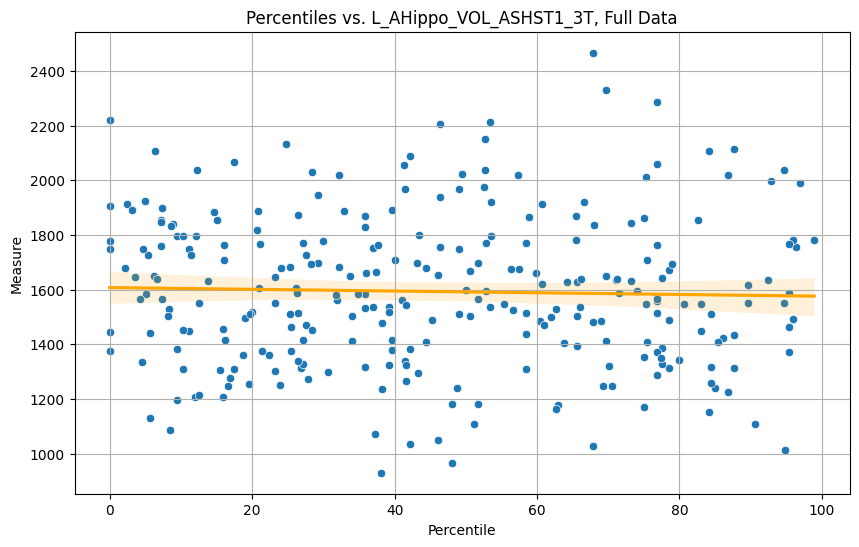

Linear regression results for L_PHippo_VOL_ASHST1_3T, full data:
Slope of the regression line: -0.19562149542519952


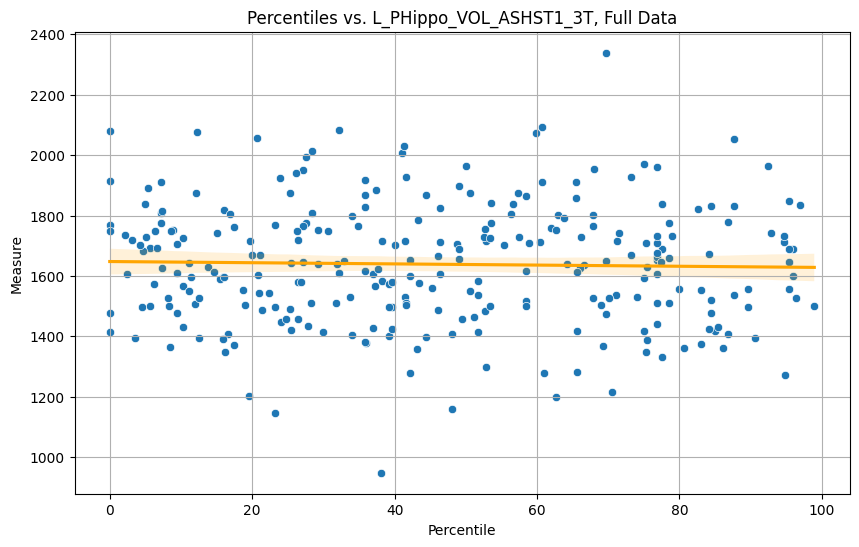

Linear regression results for R_AHippo_VOL_ASHST1_3T, full data:
Slope of the regression line: -0.38052581954631676


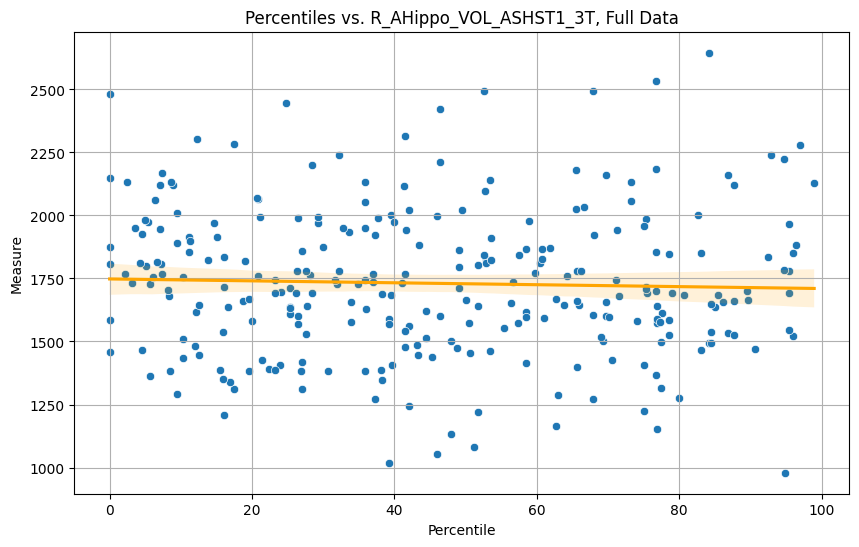

Linear regression results for R_PHippo_VOL_ASHST1_3T, full data:
Slope of the regression line: -0.09158139875246075


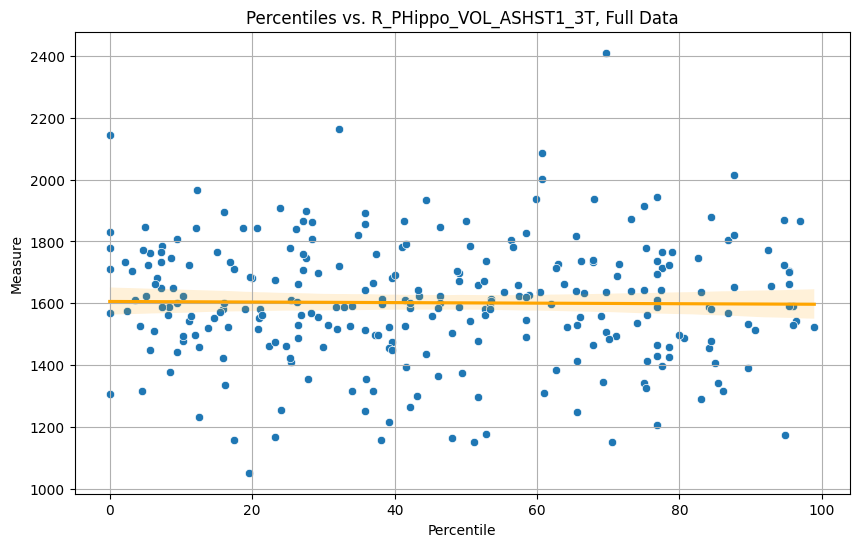

Linear regression results for L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T, full data:
Slope of the regression line: -0.00016022901806765787


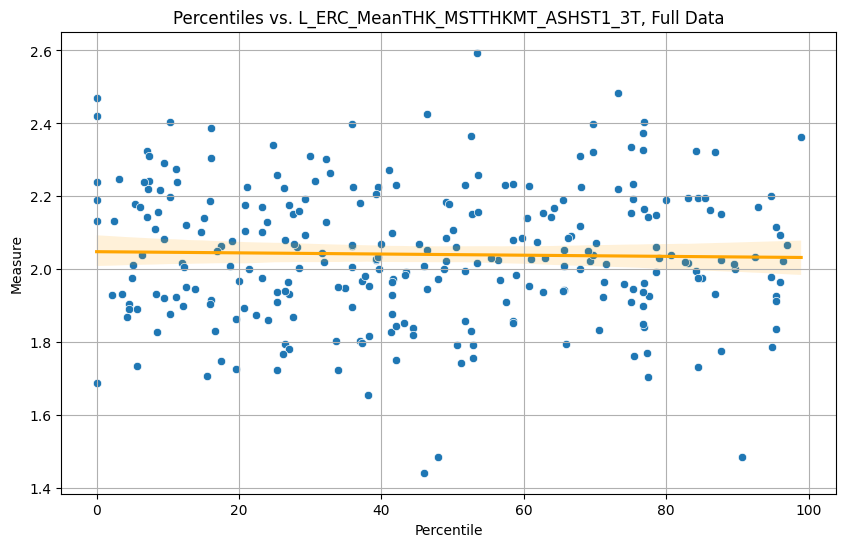

Linear regression results for R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T, full data:
Slope of the regression line: -7.040917167653133e-05


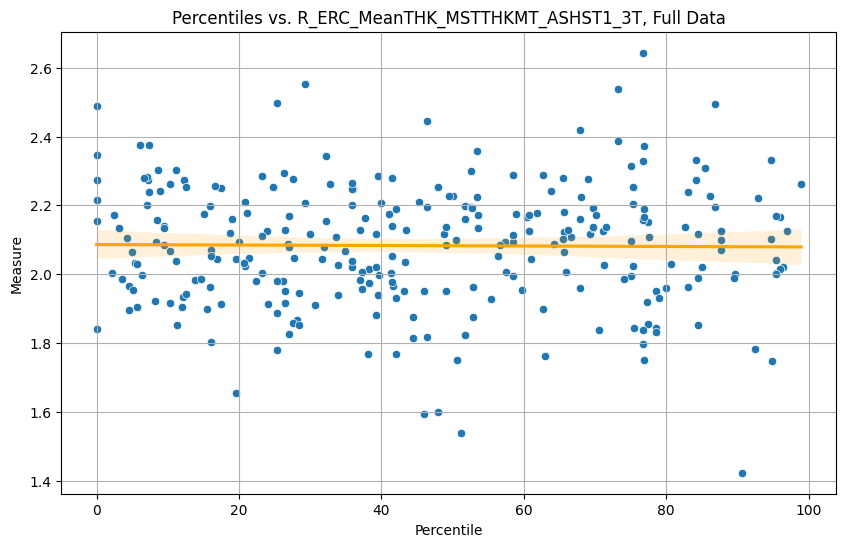

Linear regression results for Right_MFC_medial_frontal_cortex_thickness, full data:
Slope of the regression line: -0.002154280620769573


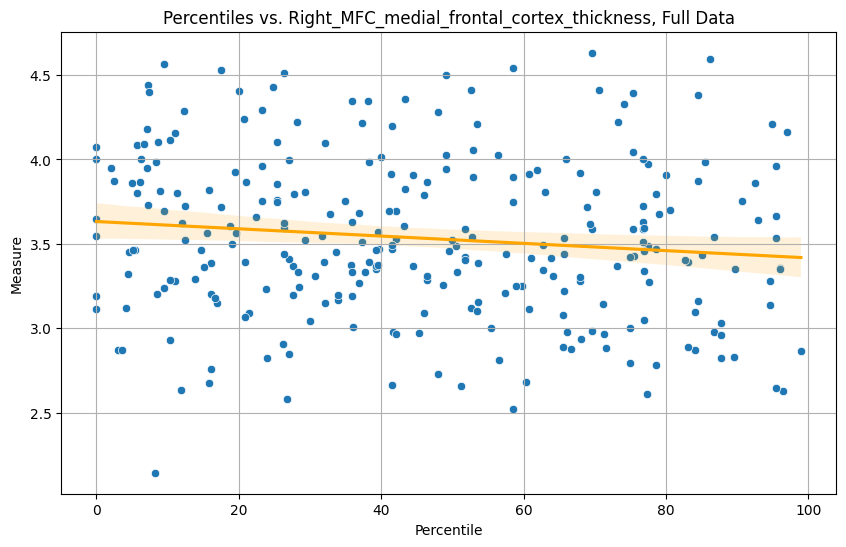

Linear regression results for Left_MFC_medial_frontal_cortex_thickness, full data:
Slope of the regression line: -0.001243450334492152


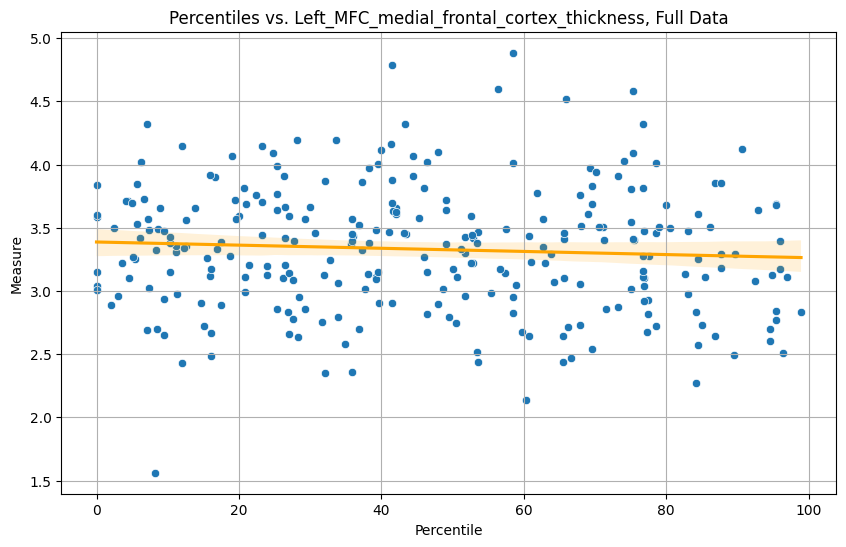

In [ ]:
# Merging penn_only_data with thickness_data and volume_data
# Using to make plots (and run regression on) full penn data

full_penn_data_quart = pd.merge(penn_only_data, thickness_data, on='INDDID')
full_penn_data_quart = pd.merge(full_penn_data_quart, volume_data, on='INDDID')
#print(full_penn_data_quart.head())


# Adding AgeAtScan column to use as covariate in linear regression: NACCAGE + MRI_Cog_test_distance (in years)
# First, calculate the days difference between the dates
full_penn_data_quart['difference_days'] = (full_penn_data_quart['MRIDATE'] - full_penn_data_quart['TESTDATE']).dt.days

# Convert positive differences into years and add to 'Age', leaving negatives unchanged
full_penn_data_quart['AgeAtScan'] = full_penn_data_quart['NACCAGE'] + full_penn_data_quart['difference_days'].apply(lambda x: x // 365 if x > 0 else 0)


# Dropping rows with NA
full_penn_data_quart = full_penn_data_quart.dropna(subset=['Right_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'Left_ACgG_anterior_cingulate_gyrus_thickness',
                                                   'L_AHippo_VOL_ASHST1_3T', 'L_PHippo_VOL_ASHST1_3T',
                                                   'R_AHippo_VOL_ASHST1_3T', 'R_PHippo_VOL_ASHST1_3T',
                                                   'L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T', 'R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T',
                               'Right_MFC_medial_frontal_cortex_thickness', 'Left_MFC_medial_frontal_cortex_thickness'])
print(len(full_penn_data_quart))


# Looping through regions to plot raw data for vulnerable regions (percentile vs measure)
for region in combined_superager_regions:
  print(f"Linear regression results for {region}, full data:")
  quartiles_plot = full_penn_data_quart['percentile_rank']
  region_plot = full_penn_data_quart[region]

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=quartiles_plot, y=region_plot, marker='o')
  sns.regplot(x=quartiles_plot, y=region_plot, scatter=False, color='orange')
  slope, intercept, r_value, p_value, std_err = stats.linregress(quartiles_plot, region_plot)

  print("Slope of the regression line:", slope)

  plt.title(f"Percentiles vs. {region}, Full Data")
  plt.xlabel('Percentile')
  plt.ylabel('Measure')
  plt.grid(True)
  plt.show()

In [ ]:
# Performing linear regression on full data to look at volume/thickness measures against percentile

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Store results from linear regression
results_full = []

# Create list of just p-values
p_values = []

# Create list of r-squared values
r_squared = []


# Perform linear regression for each region
for region in combined_superager_regions:
  print(f"Linear regression results for {region}, full data:")
  #percentiles = full_penn_data_quart['percentile_rank']

  # Assign variables of interest and add a constant for the intercept
  # Define the dependent variable (ROI volume) and independent variables (percentile, ICV, AgeAtScan, and MRI_Cog_test_distance)
  X = full_penn_data_quart[['percentile_rank', 'ICV_ASHST1_3T', 'AgeAtScan', 'MRI_Cog_test_distance']]
  X = sm.add_constant(X)
  y = full_penn_data_quart[region]

  # Convert 'MRI_Cog_test_distance' to total days and then to numeric, handling potential errors
  X['MRI_Cog_test_distance'] = pd.to_numeric(X['MRI_Cog_test_distance'].dt.days, errors='coerce')

  # Ensure all other columns in X and y are numeric
  # This handles cases where columns might have been interpreted as objects
  for col in X.columns:
      if X[col].dtype != 'float64' and X[col].dtype != 'int64':
          X[col] = pd.to_numeric(X[col], errors='coerce')
  y = pd.to_numeric(y, errors='coerce')

  # Fit the model
  model = sm.OLS(y, X).fit()

  # Extract relevant information
  percent_coef = model.params['percentile_rank']
  percent_pval = model.pvalues['percentile_rank']

  # Append results to the list
  results_full.append({'ROI': region, 'Percentile_Coefficient': percent_coef, 'Percentile_p_value': percent_pval})

  # Append p-values to p-value list for significance plotting
  p_values.append(percent_pval)

  # Append r-squared values to list for effect size calculation
  r_squared.append({region: model.rsquared})

# Convert results to a DataFrame
results_df = pd.DataFrame(results_full)

# Display the results DataFrame
print(results_df)

# Save full merged df
full_penn_data_quart_path = '/content/drive/Shareddrives/Cognitive Age Project/full_penn_data_quart.csv'
full_penn_data_quart.to_csv(full_penn_data_quart_path, index=False)

Linear regression results for Right_ACgG_anterior_cingulate_gyrus_thickness, full data:
Linear regression results for Left_ACgG_anterior_cingulate_gyrus_thickness, full data:
Linear regression results for L_AHippo_VOL_ASHST1_3T, full data:
Linear regression results for L_PHippo_VOL_ASHST1_3T, full data:
Linear regression results for R_AHippo_VOL_ASHST1_3T, full data:
Linear regression results for R_PHippo_VOL_ASHST1_3T, full data:
Linear regression results for L_ERC_MeanTHK_MSTTHKMT_ASHST1_3T, full data:
Linear regression results for R_ERC_MeanTHK_MSTTHKMT_ASHST1_3T, full data:
Linear regression results for Right_MFC_medial_frontal_cortex_thickness, full data:
Linear regression results for Left_MFC_medial_frontal_cortex_thickness, full data:
                                             ROI  Percentile_Coefficient  \
0  Right_ACgG_anterior_cingulate_gyrus_thickness               -0.001845   
1   Left_ACgG_anterior_cingulate_gyrus_thickness               -0.001280   
2                   

In [ ]:
# Calculate effect size using r-squared values and do power analysis
from statsmodels.stats.power import FTestPower


# Convert r_squared to a dictionary
r_squared_dict = {list(d.keys())[0]: list(d.values())[0] for d in r_squared}

# Calculate f^2 (effect size) for each region
effect_sizes = {region: r2 / (1 - r2) for region, r2 in r_squared_dict.items()}
print(effect_sizes)

# Pooled effect size by averaging individual effect sizes
pooled_f2 = sum(effect_sizes.values()) / len(effect_sizes)
print(pooled_f2)

# Parameters
effect_size = 0.18
alpha = 0.05
power = 0.80
num_predictors = 1

# Create a power analysis object
power_analysis = FTestPower()

# Calculate required sample size
n_pooled = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, df_num=num_predictors)
print(f"Required sample size (pooled): {n_pooled}")

Required sample size (pooled): [3.]


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)
